In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import pandas as pd
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import scipy as sp

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [2]:
COLOR_MAP = {
                'mediumblue': "Unstable Focus",
                'darkgreen': "Stable Node",
                'red': "Unstable Saddle Point",
                'saddlebrown': "Stable Spiral",
                'purple': "Unstable Spiral",
                'black': "Circle"
            }

In [3]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_01/fp"
os.makedirs(figureroot, exist_ok=True)

In [4]:
load_dir = "../system_01/results/fp/"
load_str = datetime.datetime(2024, 2, 10)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 130


In [5]:
filePaths = [path for path in file_paths if '_K_' in path]

# sorting based on sigma value
sigma_lookup = {}
k_lookup = {}

for n, filePath in enumerate(filePaths):
    baseName = os.path.basename(filePath)
    sig_val = float(baseName.split('_')[3])
    k_val = float(baseName.split('_')[-1][:-4])

    if sig_val not in sigma_lookup.keys():
        sigma_lookup[sig_val] = [filePath]
        k_lookup[sig_val] = [k_val]
    else:
        sigma_lookup[sig_val].append(filePath)
        k_lookup[sig_val].append(k_val)
    

for key, vals in k_lookup.items():
    k_vals = np.array(vals)
    ksort = np.argsort(k_vals)

    sigma_lookup[key] = np.array(sigma_lookup[key])[ksort]

sigma_vals = np.array(list(sigma_lookup.keys()))
sigSort = np.argsort(sigma_vals)

filePathsSort = []

for n in sigSort:
    sigma_key = sigma_vals[n]
    filePathsSort += list(sigma_lookup[sigma_key])

filePathsSort = np.array(filePathsSort)

In [6]:
sigValues = np.arange(2.5, 18.5, 1.25)
kValues = np.array([-0.8, -0.2, 0.0, 0.2, 0.8])

iMin = -0.25; iMax = 0.25; iSteps = 500
iValues = iMin + np.arange(0, iSteps + 1) / iSteps * (iMax - iMin)

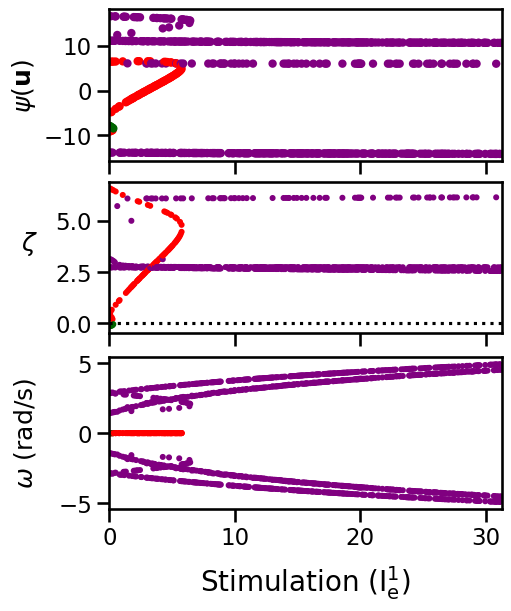

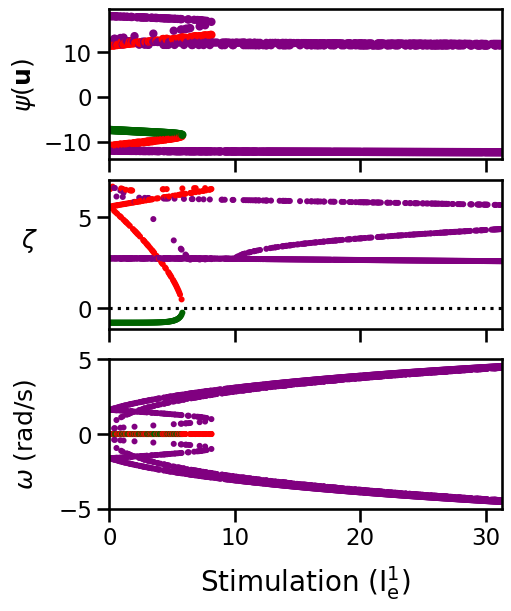

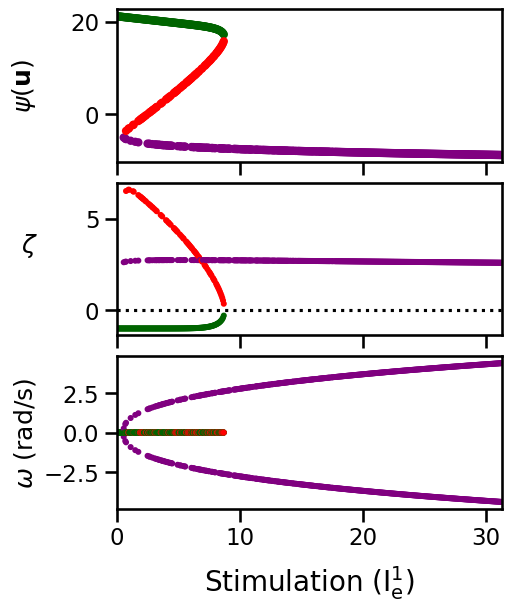

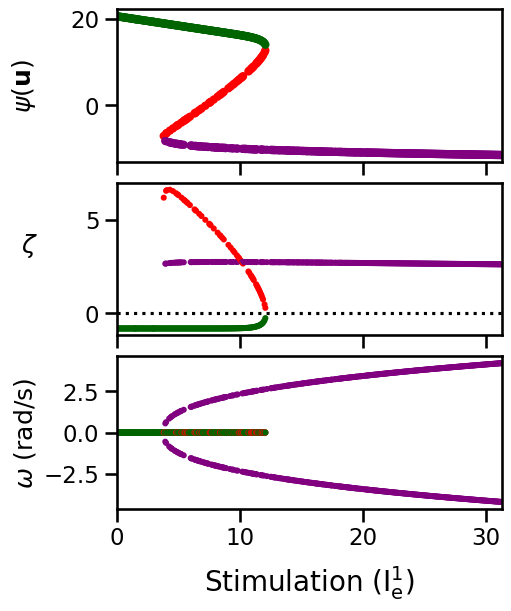

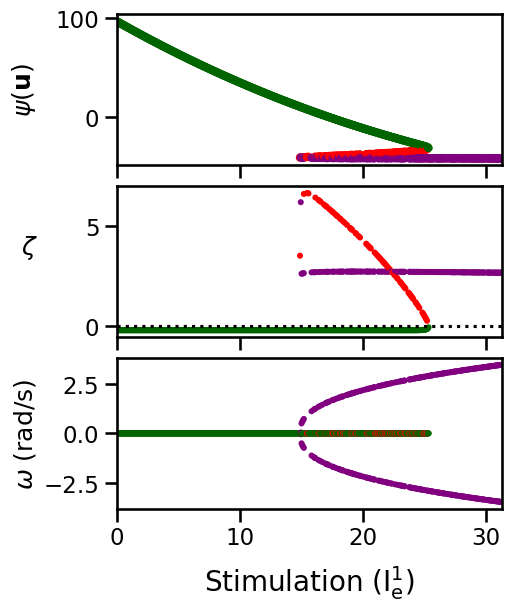

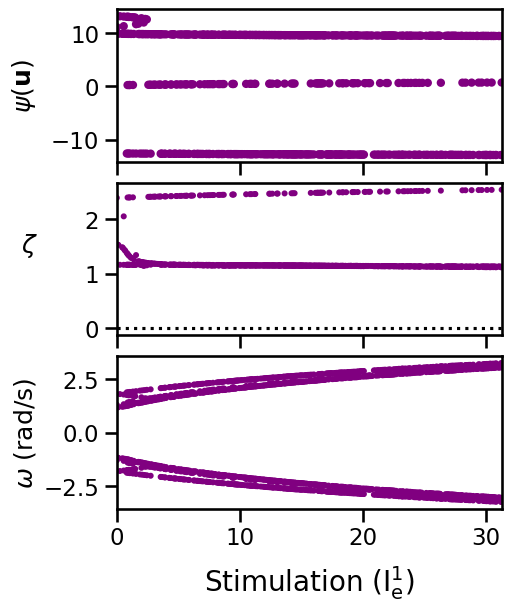

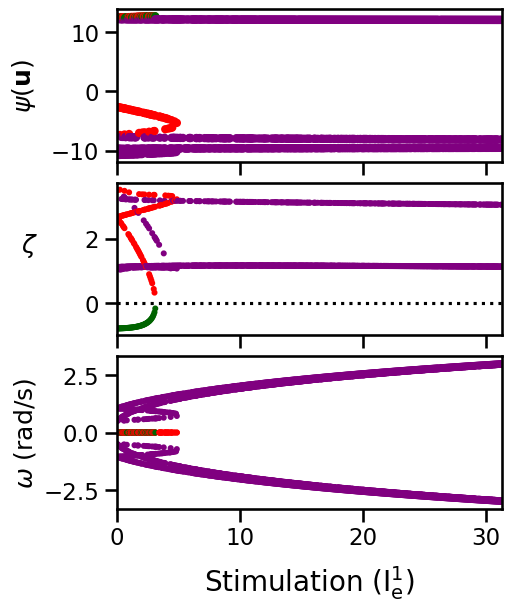

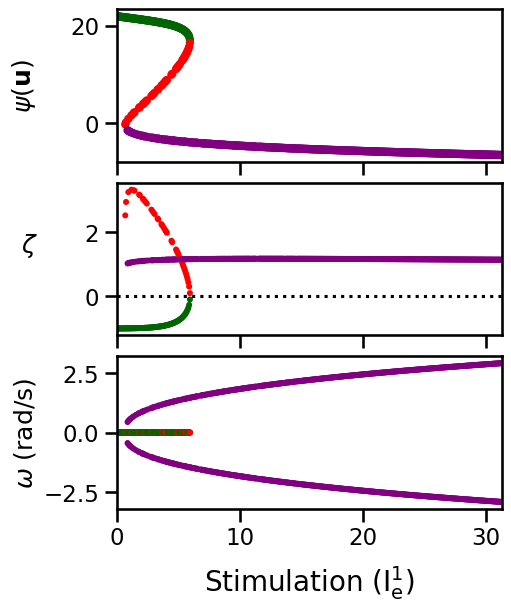

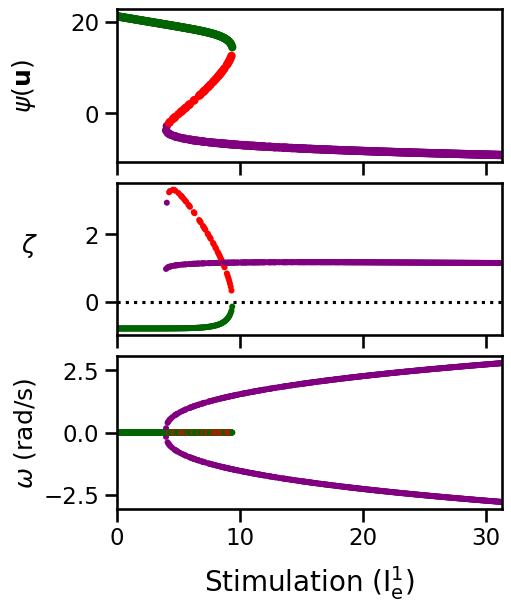

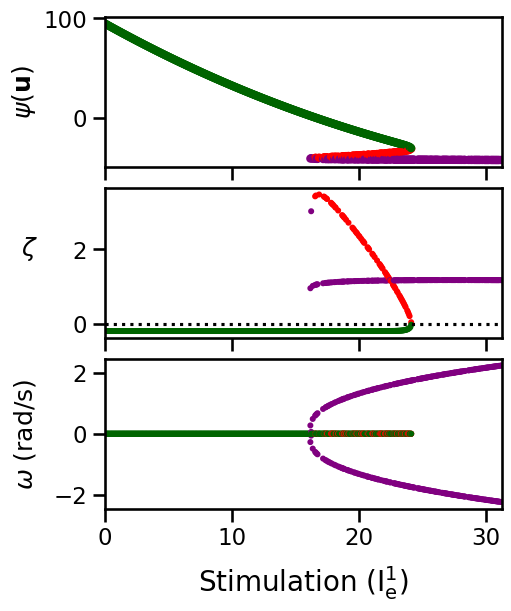

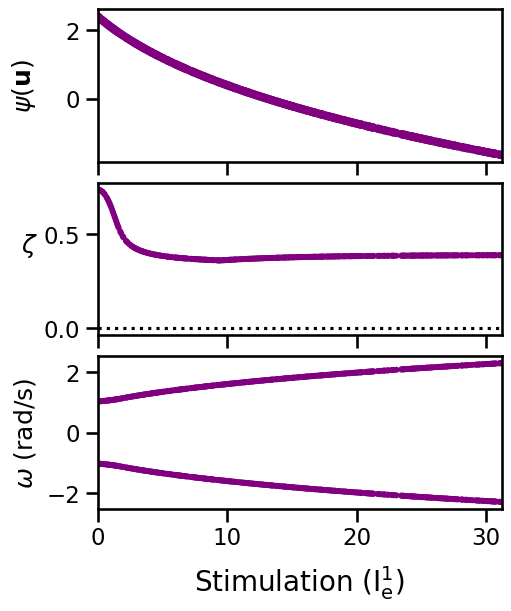

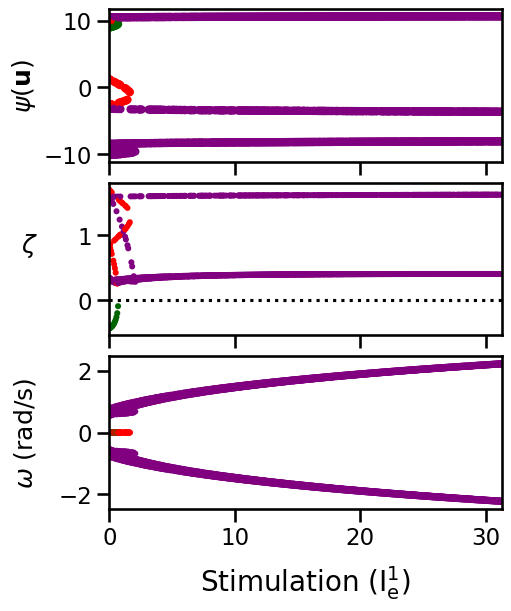

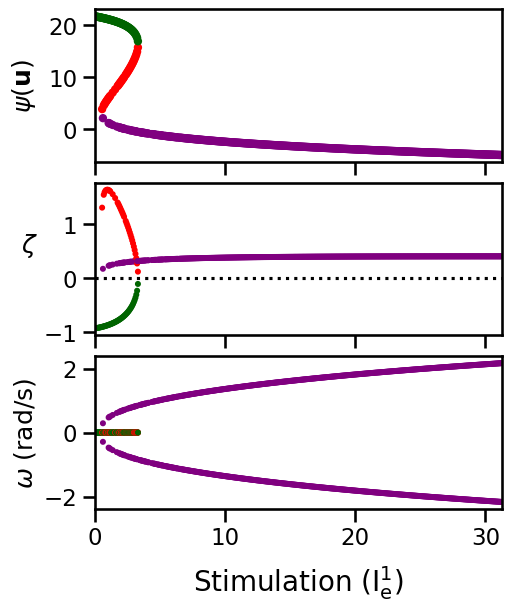

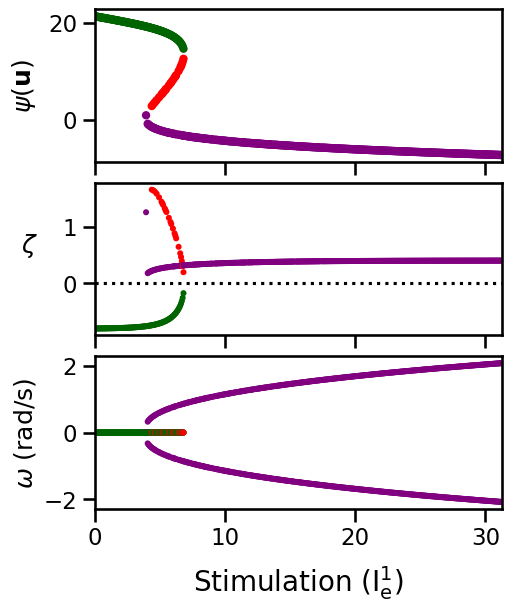

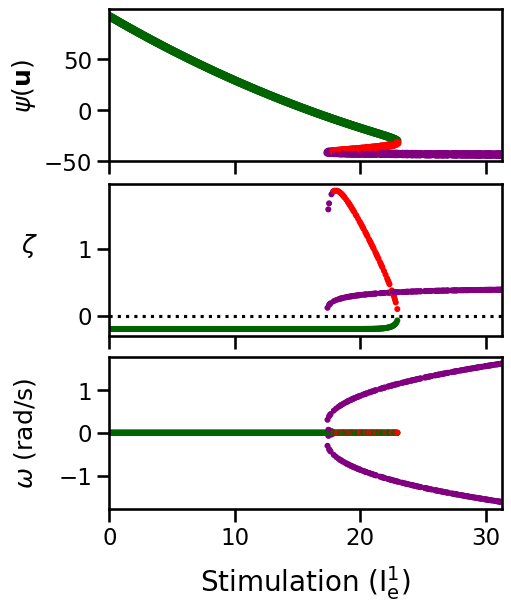

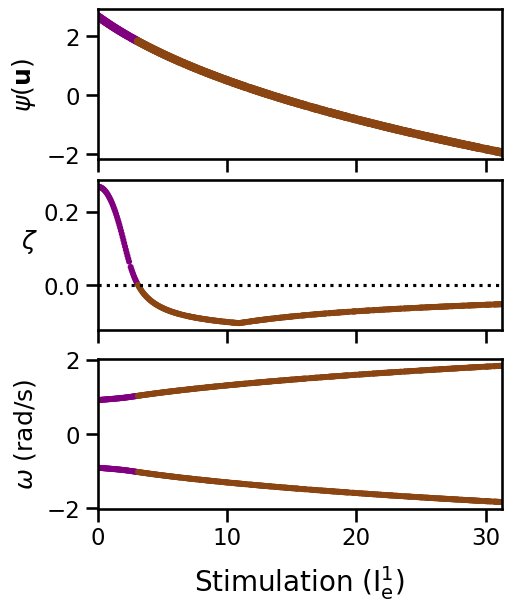

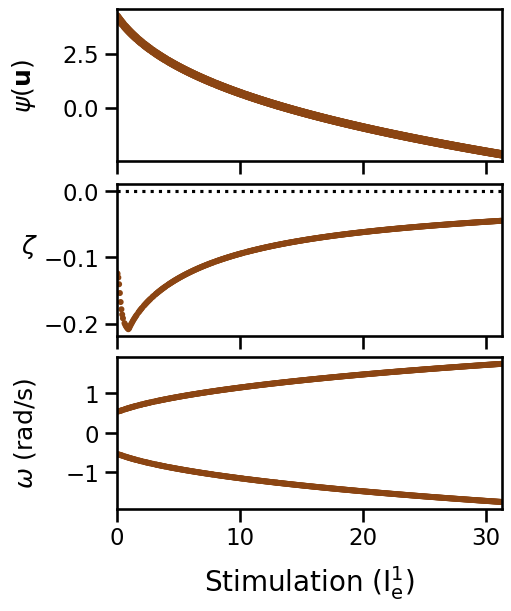

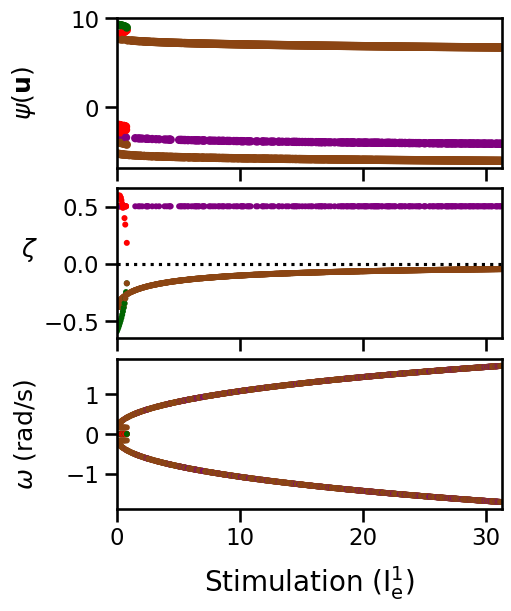

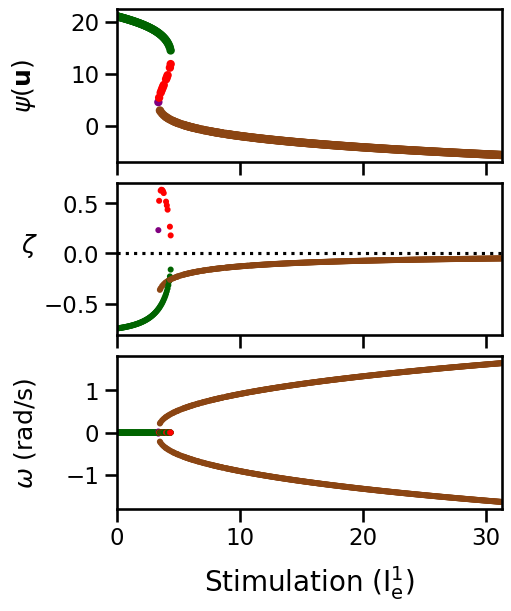

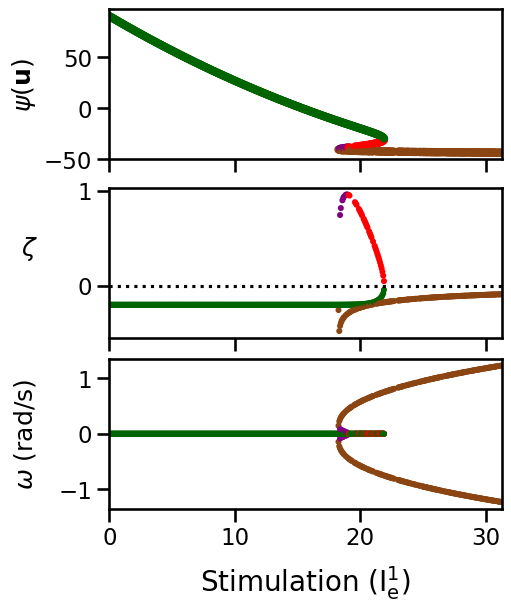

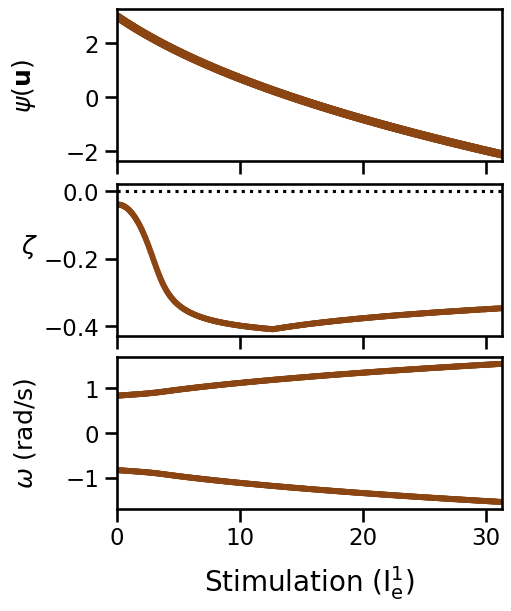

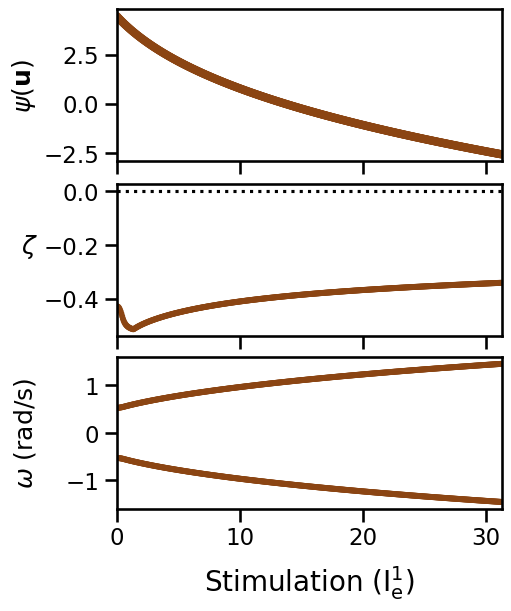

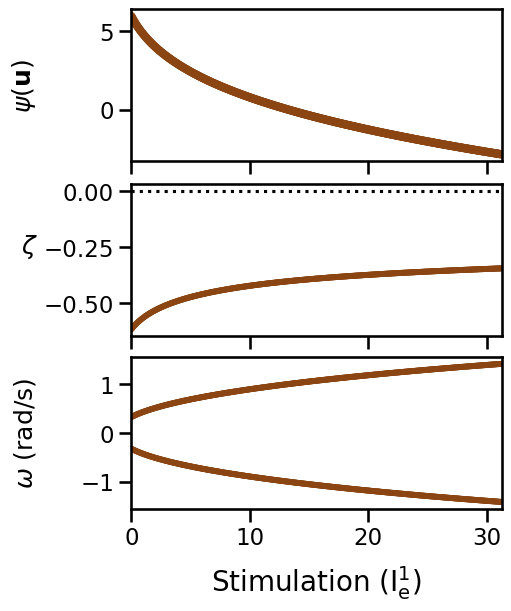

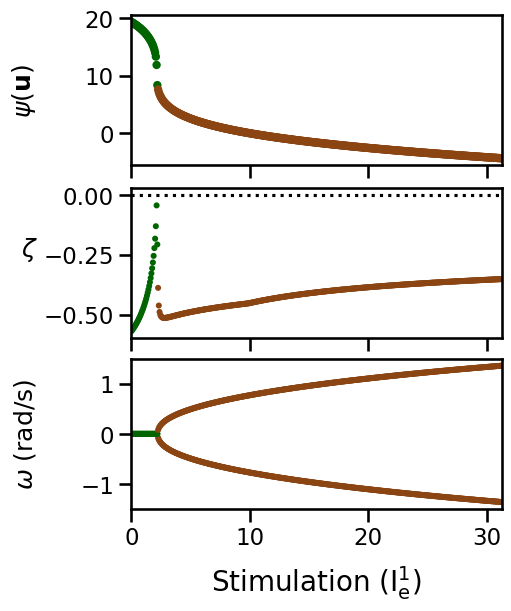

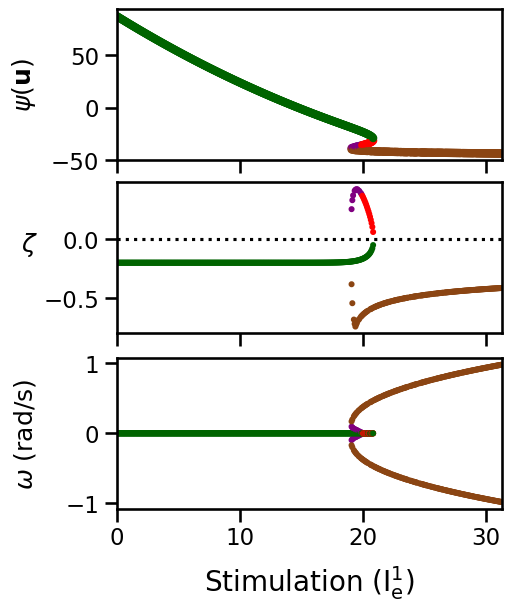

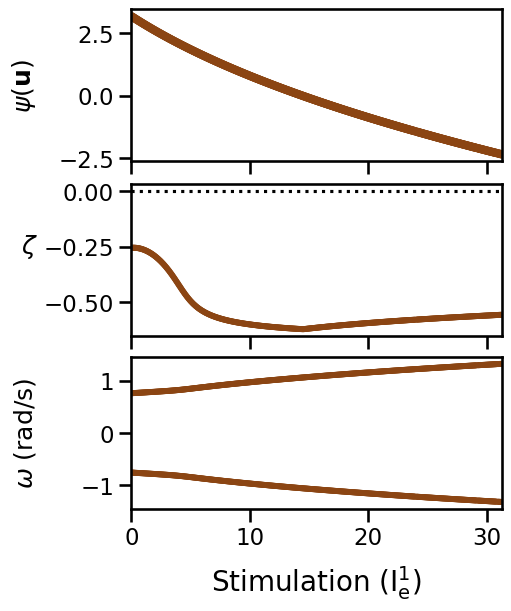

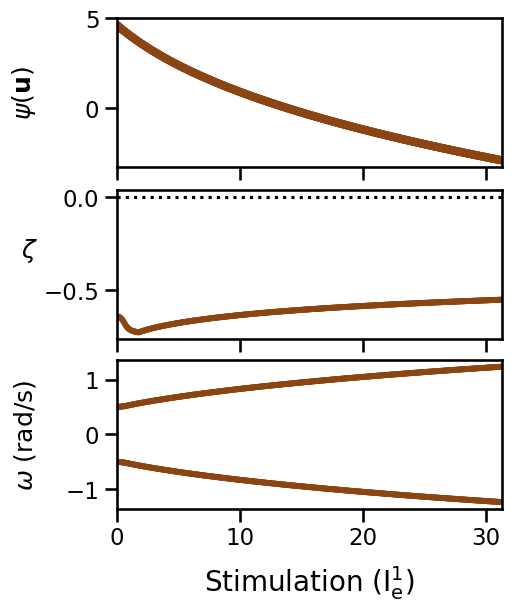

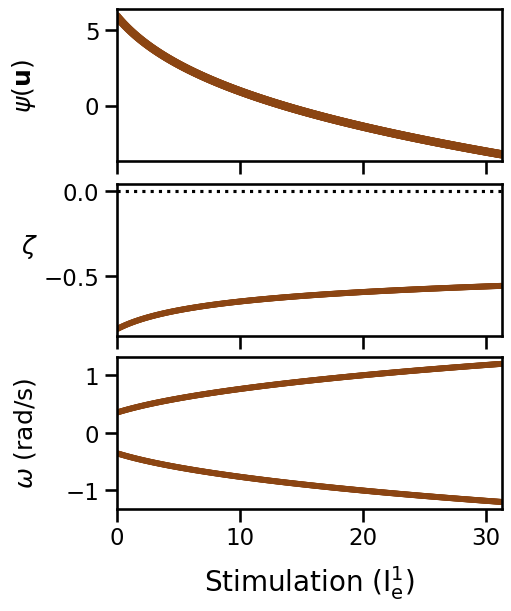

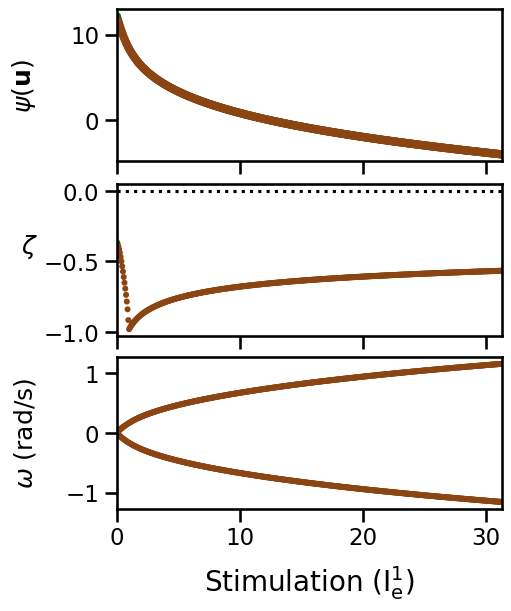

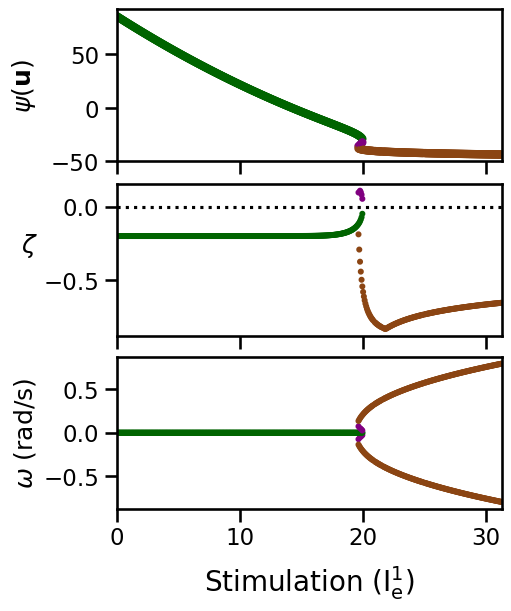

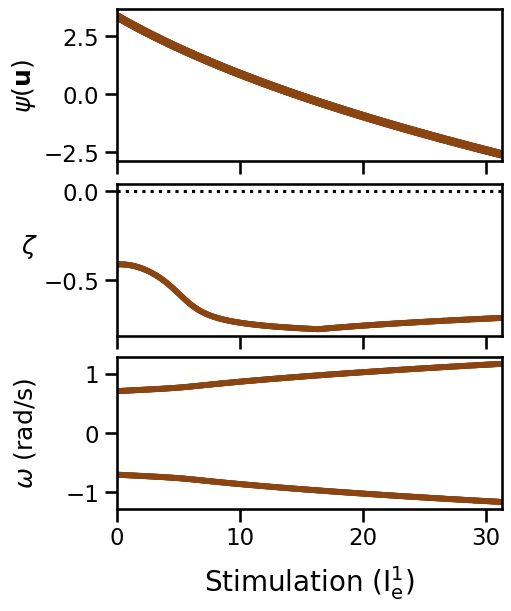

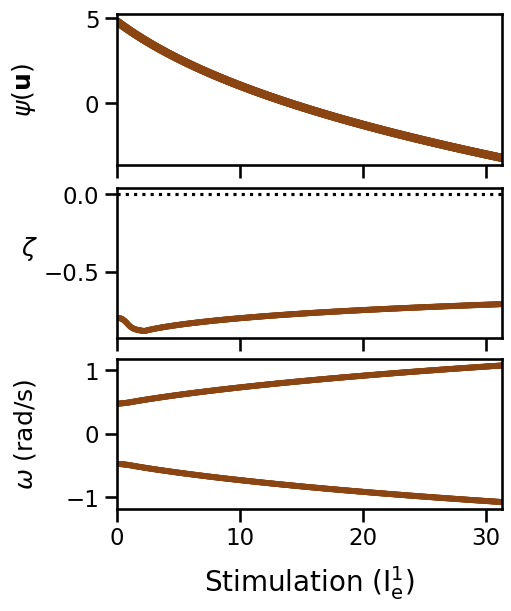

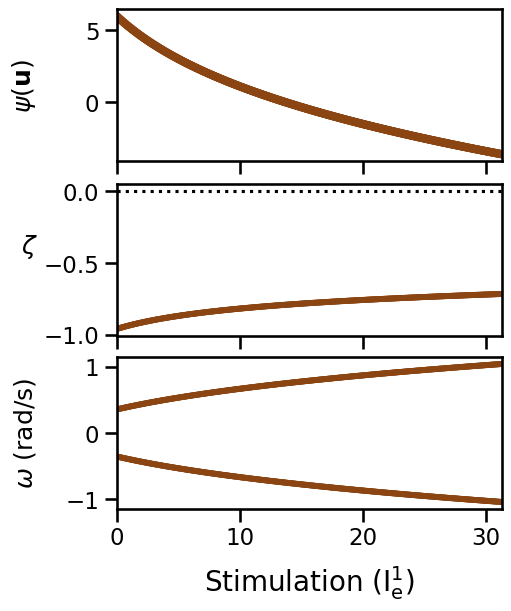

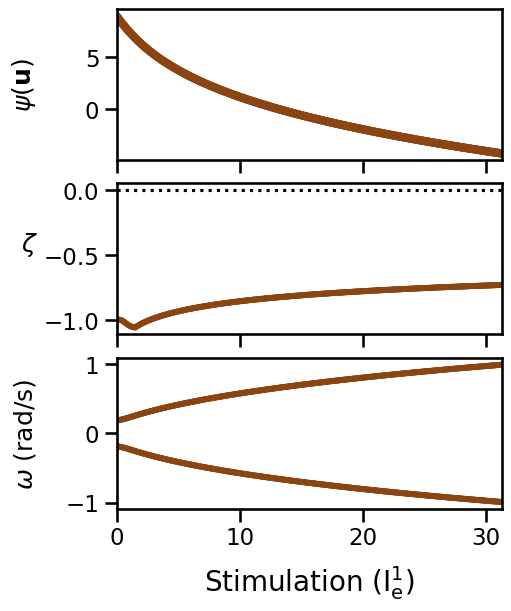

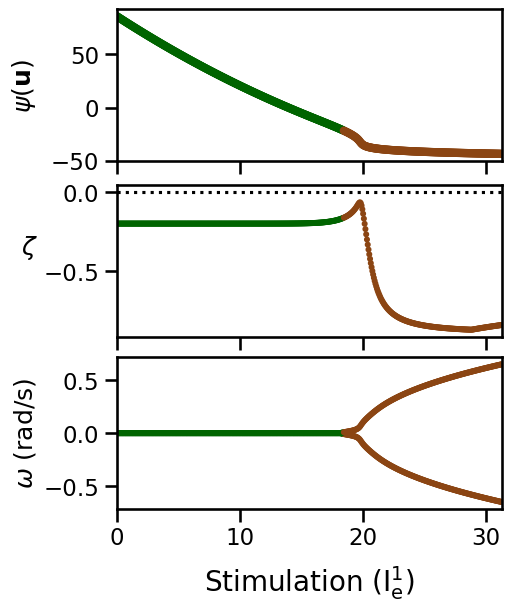

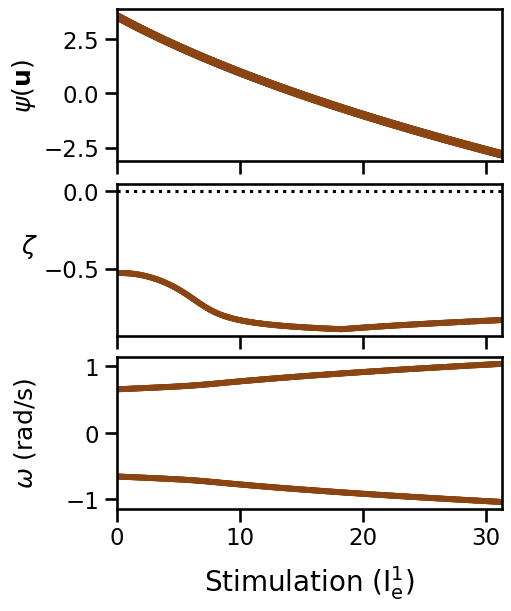

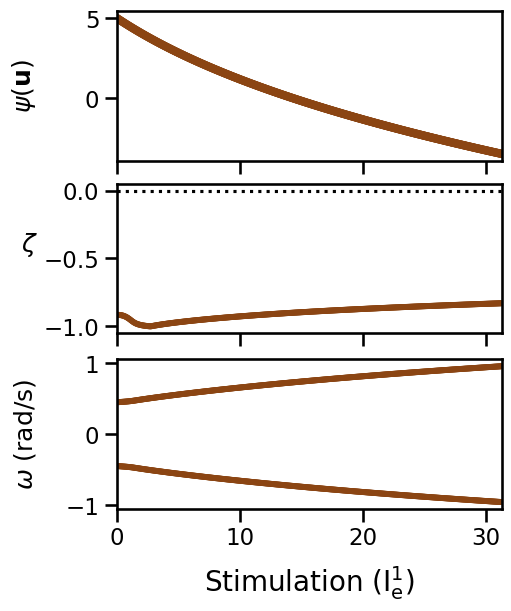

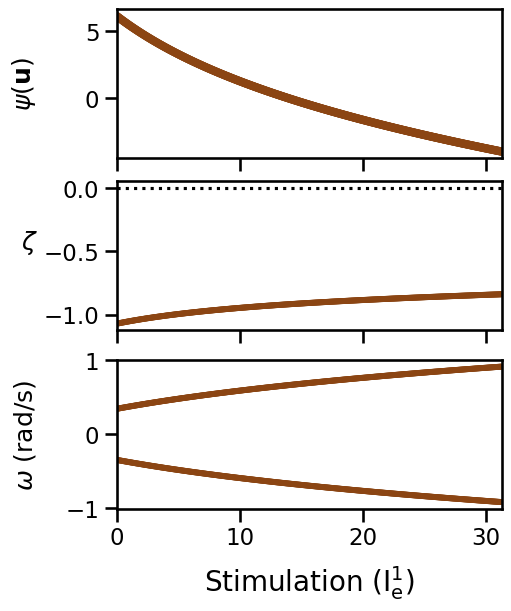

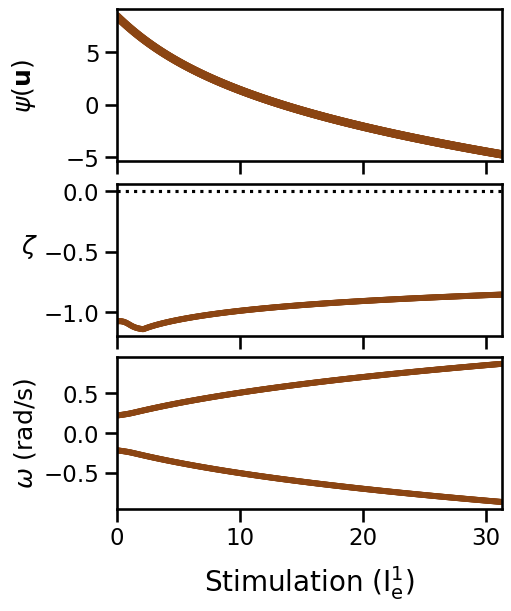

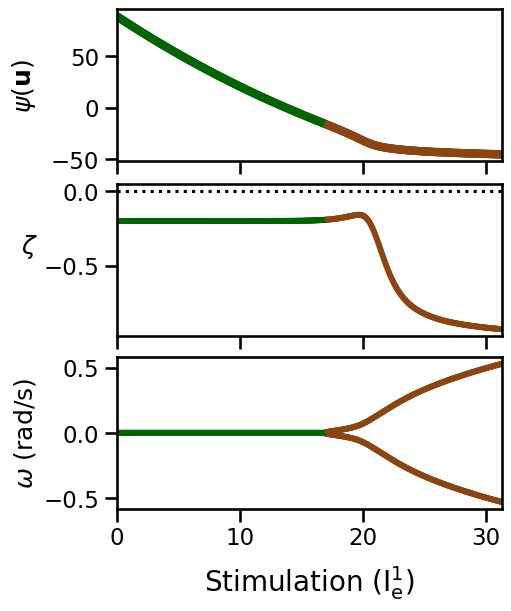

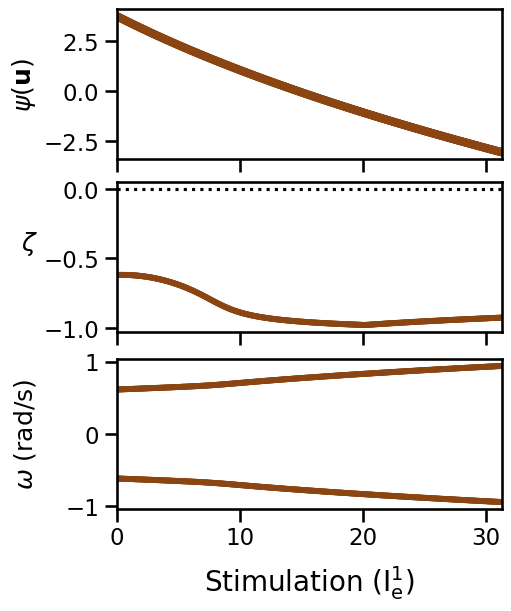

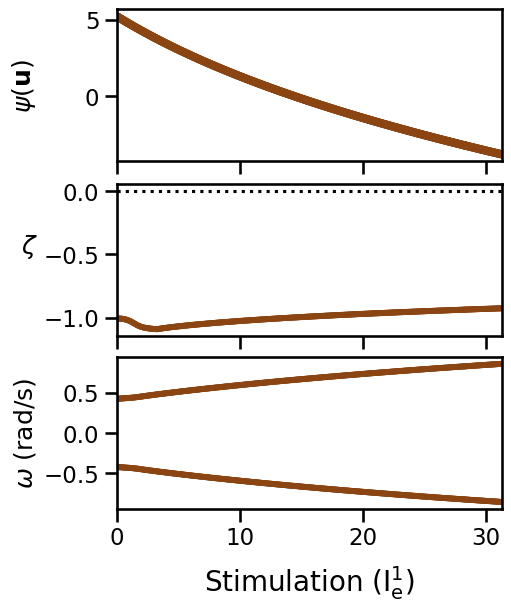

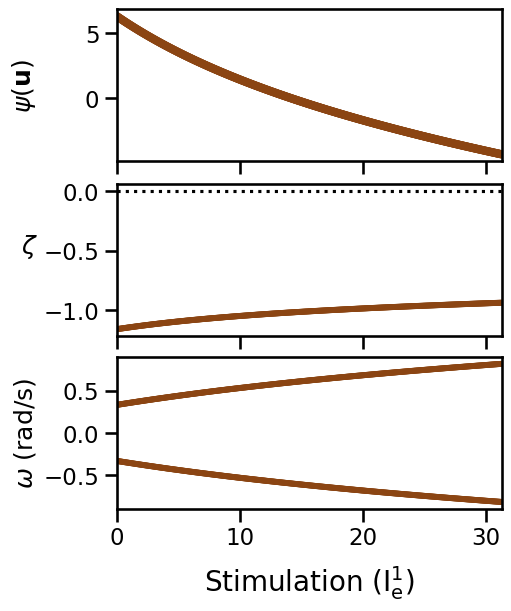

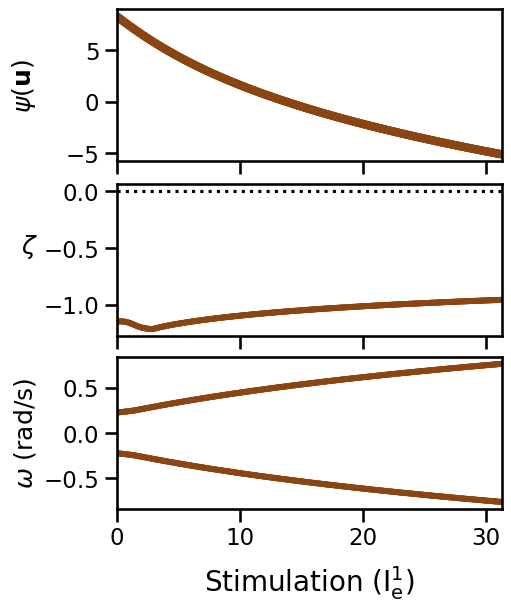

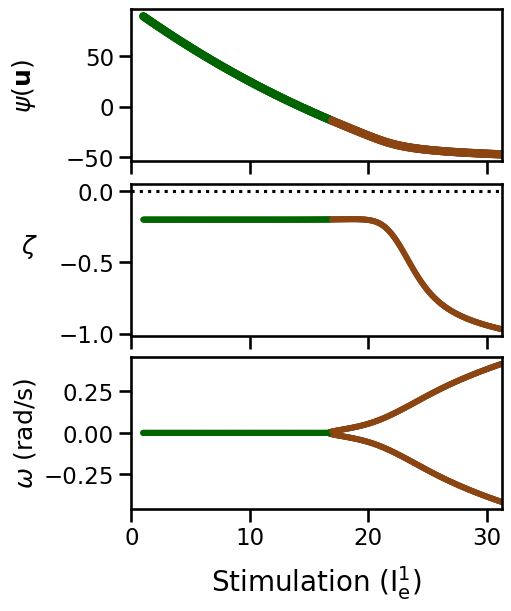

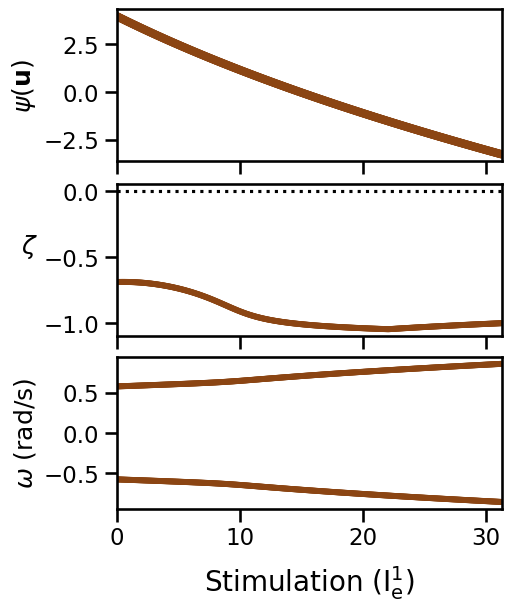

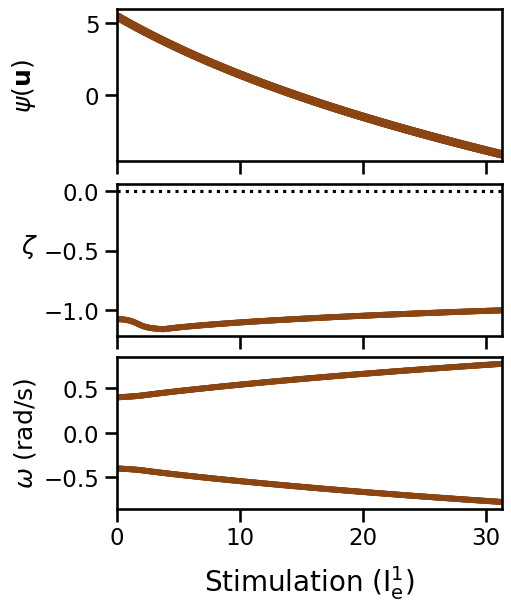

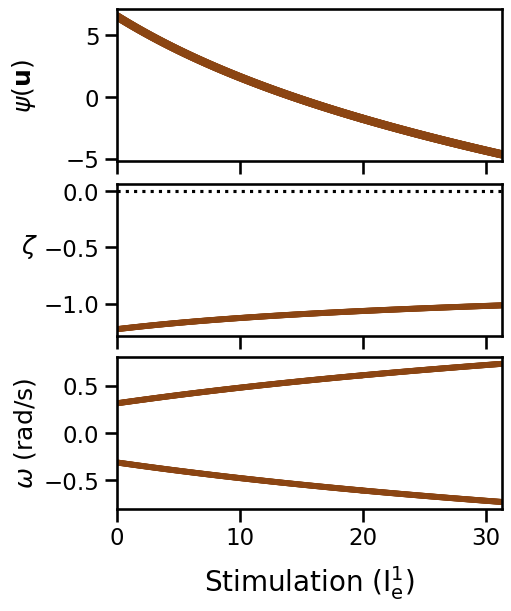

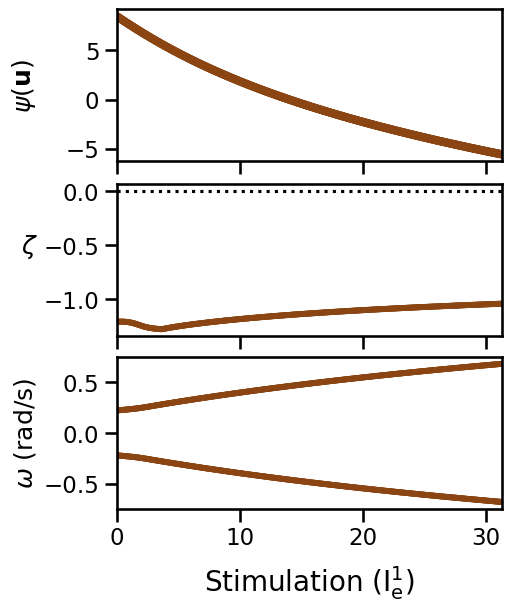

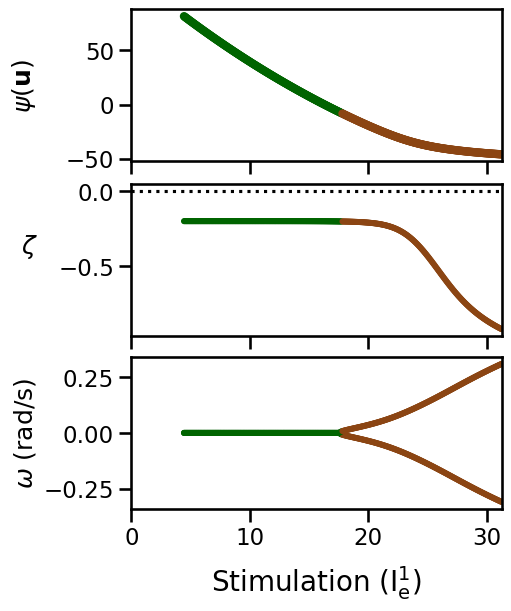

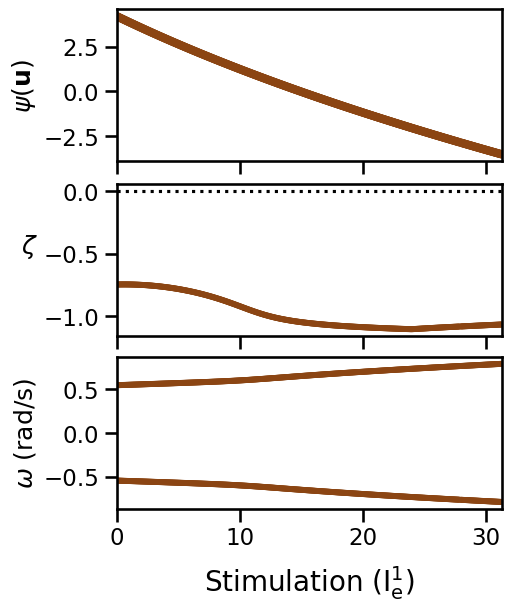

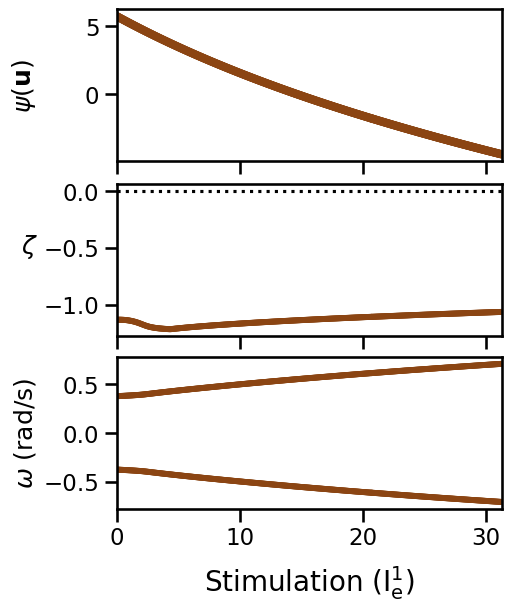

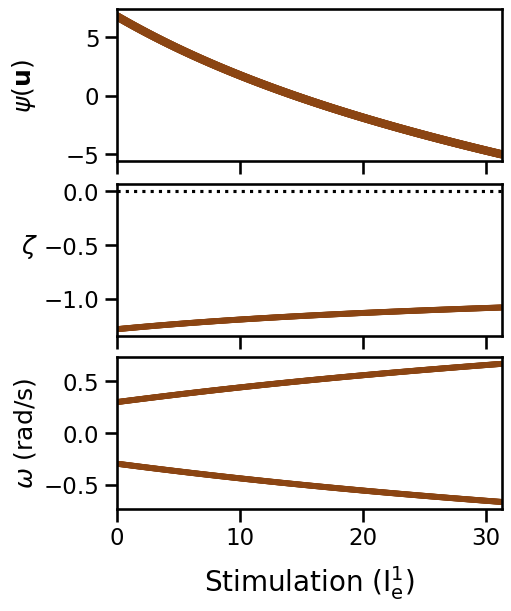

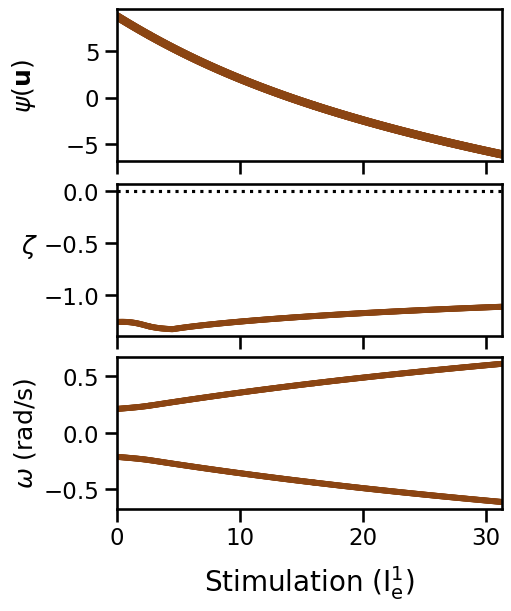

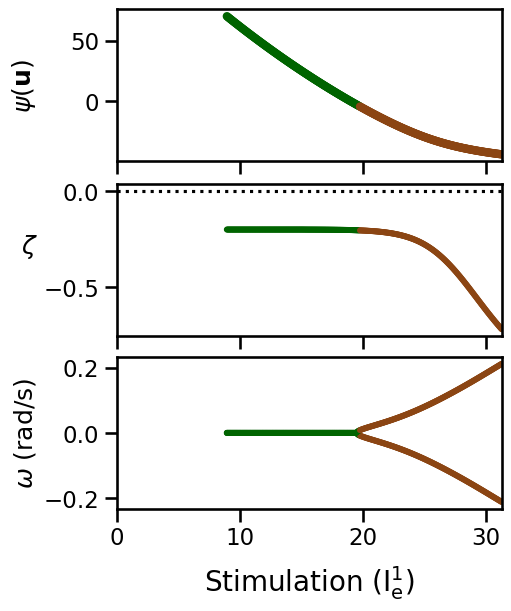

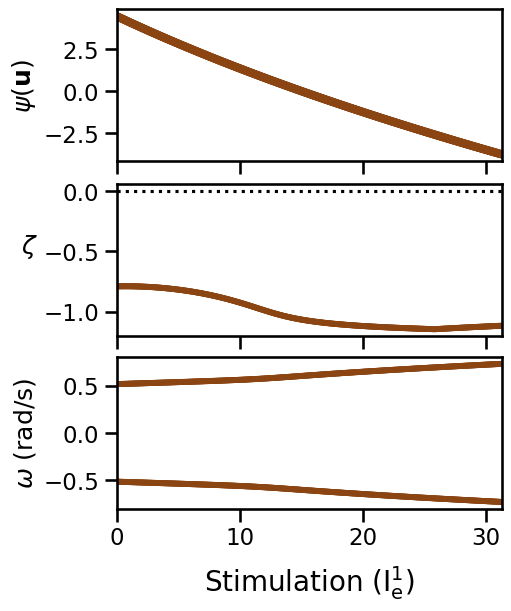

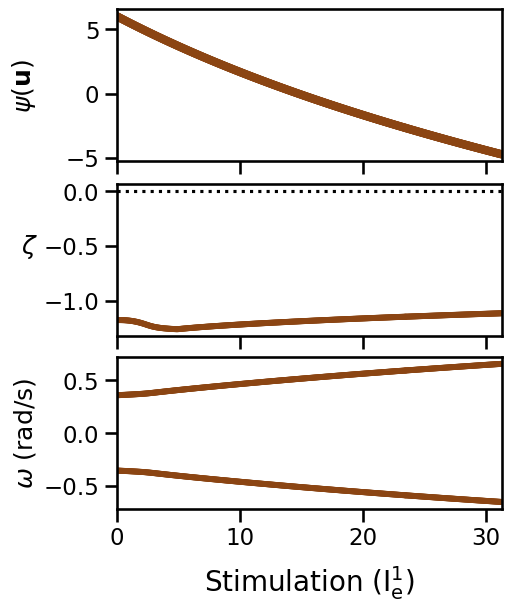

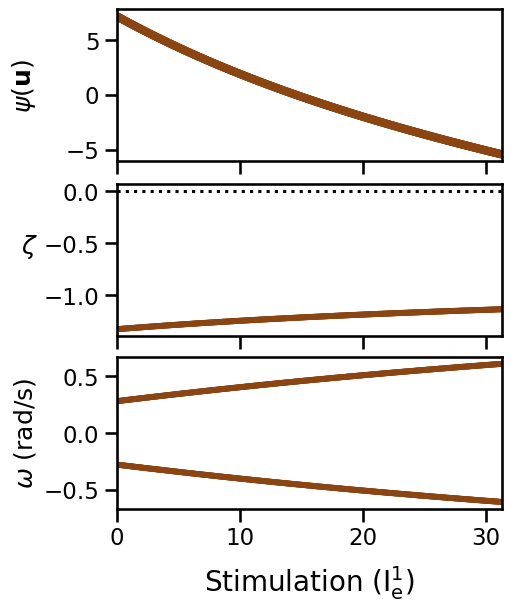

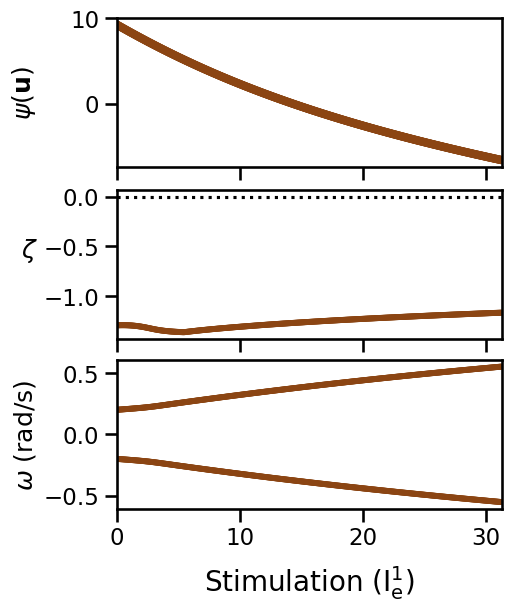

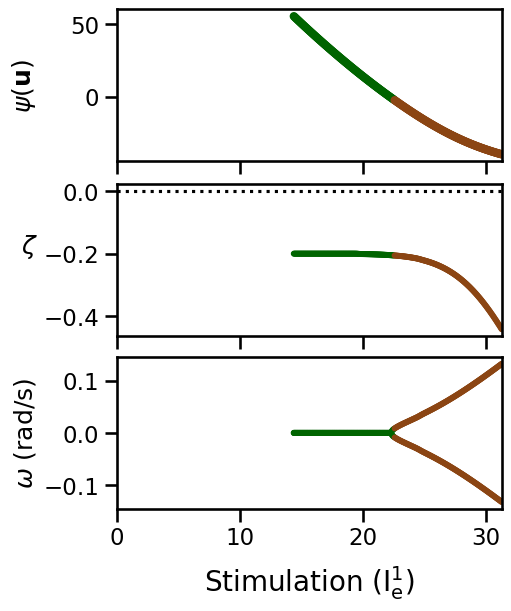

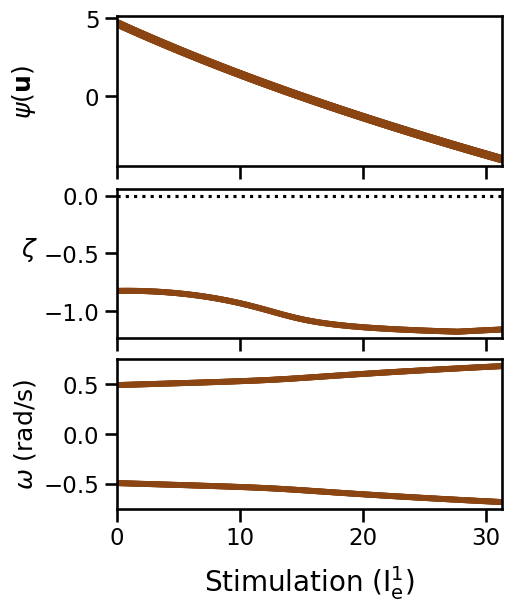

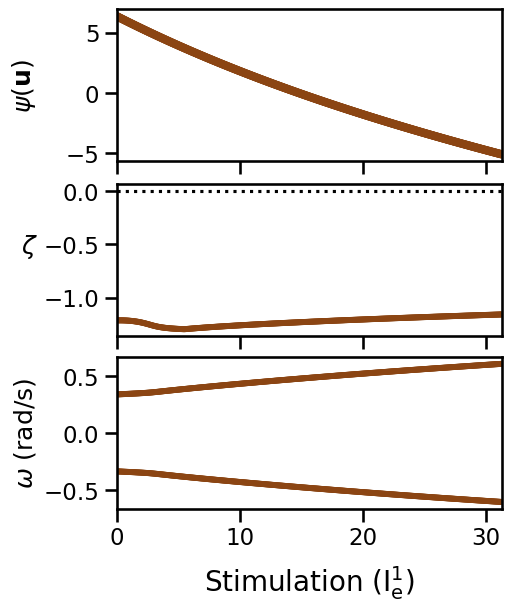

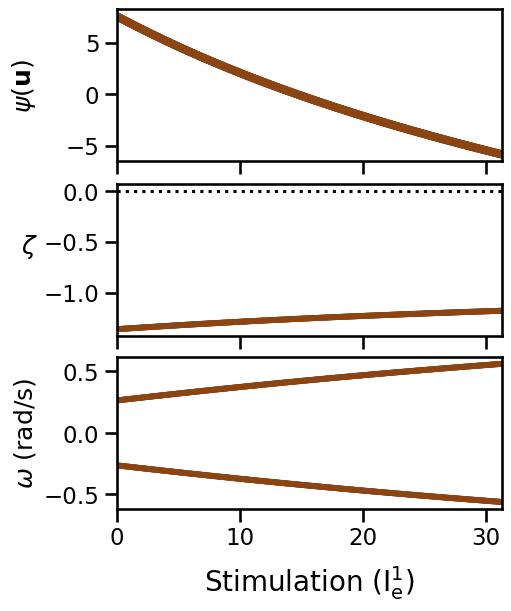

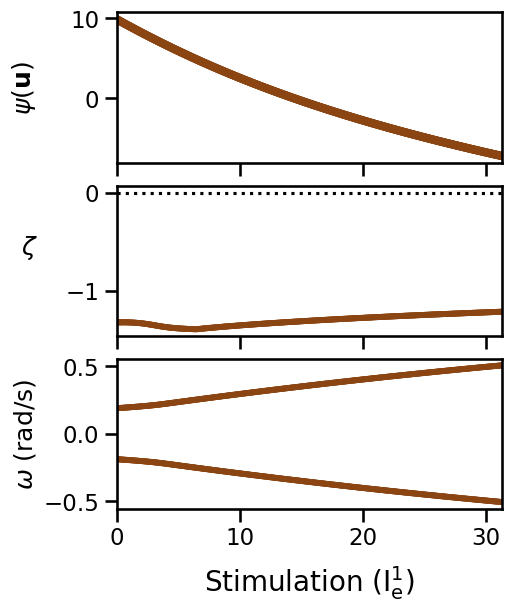

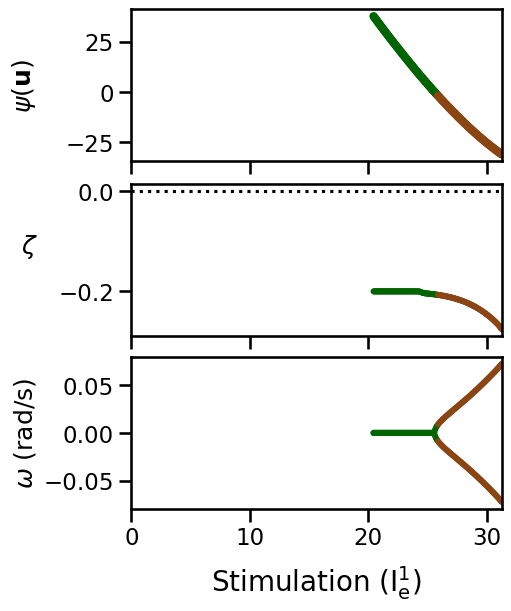

In [ ]:
for filePath in filePathsSort:
    BaseName = os.path.basename(filePath).split('.pkl')[0]
    K = float(BaseName.split('_')[-1])
    Sig = float(BaseName.split('_')[3])

    if K != 0.8:
        continue
    
    with open(filePath, 'rb') as file_:
        DataDict = pickle.load(file_)
    
    params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = Sig
    params['K'] = K
    
    plot_dict = {'fig_size': (10, 8), 'xlabel': r"$I^1_e$", 'var_name': 'external stimulus'}
    file_str_k = f"K_{K:.3f}_sig_{Sig:.3f}.jpg"

    fpList = []
    for _, fps in DataDict['fps'].items():
        fpList.append(fps)
    
    fpList = np.array(fpList)
    eig_dict = calc_jacobian(fpList.T, **params)

    eigVals = eig_dict['eigvals']

    I = np.array(DataDict['fp_var']) / params['gamma'] - params['i_e2']

    decayRates = []
    OscilRate1 = []
    OscilRate2 = []

    for ne, eigSpectrum in enumerate(eigVals):
        signifOrder = np.argsort(eigSpectrum.real)[::-1]
        decayRate = eigSpectrum[signifOrder][0].real

        signifOrder = np.argsort(np.abs(eigSpectrum.imag))[::-1]
        Omega = eigSpectrum[signifOrder][:2].imag / (2 * np.pi)

        # adjutsment
        imag_ = eigSpectrum[signifOrder].imag
        imag_ = np.round(imag_, 1)
        if (imag_ == 0).all():
            if DataDict['fp_types']['ue1'][ne] == 'purple':
                DataDict['fp_types']['ue1'][ne] = 'red'
                DataDict['fp_types']['ui1'][ne] = 'red'
                DataDict['fp_types']['ue2'][ne] = 'red'
                DataDict['fp_types']['ui2'][ne] = 'red'
            
            if DataDict['fp_types']['ue1'][ne] == 'saddlebrown':
                DataDict['fp_types']['ue1'][ne] = 'darkgreen'
                DataDict['fp_types']['ui1'][ne] = 'darkgreen'
                DataDict['fp_types']['ue2'][ne] = 'darkgreen'
                DataDict['fp_types']['ui2'][ne] = 'darkgreen'

        decayRates.append(decayRate)
        OscilRate1.append(Omega[0])
        OscilRate2.append(Omega[1])

    DF = dimreduction(DataDict, xVar='I', **params)

    textDelt = max(DF['U']/ params['gamma']) * 0.5
    fig, axs = plt.subplots(3, 1, figsize=(5, 6), sharex=True, layout='constrained')
    axs[0].scatter(I, DF['U'] / params['gamma'], c=DF['FP_types'], marker='.')
    axs[0].set_ylabel(r'$\psi(\mathbf{u})$', fontsize=18)
    # axs[0].text(-5, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['purple'], c='purple')
    # axs[0].text(18, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['red'], c='red')
    # axs[0].text(18, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['black'], c='black')
    # axs[0].text(-5, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['mediumblue'], c='mediumblue')

    # axs[0].text(7, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['darkgreen'], c='darkgreen')
    # axs[0].text(7, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['saddlebrown'], c='saddlebrown')
    

    axs[1].scatter(I, decayRates, marker='.', s = 32, c=DataDict['fp_types']['ue1'])
    axs[1].axhline(y=0, linestyle=':', color='k')
    axs[1].set_ylabel(r"$\zeta$", rotation=0, labelpad=10, fontsize=18)

    axs[2].scatter(I, OscilRate1, marker='.', s = 32, c=DataDict['fp_types']['ue1'])
    axs[2].scatter(I, OscilRate2, marker='.', s = 32, c=DataDict['fp_types']['ue1'])
    axs[2].set_ylabel(r'$\omega$ (rad/s)', fontsize=18)
    axs[2].set_xlim(0, max(I))
    axs[2].set_xlabel(r"Stimulation $(\rm I^1_e)$", labelpad=10, fontsize=20)

    fig.align_ylabels() 

    plt.savefig(os.path.join(figureroot, file_str_k), dpi=300, bbox_inches='tight')

In [8]:
# Equilibria change with K
filePaths = [path for path in file_paths if '_K_' not in path]

# sorting based on sigma value
sigma_lookup = {}
i_lookup = {}

for n, filePath in enumerate(filePaths):
    baseName = os.path.basename(filePath).split('mV.pkl')[0]
    sig_val = float(baseName.split('_')[3])
    i_val = float(baseName.split('_')[-1])

    if sig_val not in sigma_lookup.keys():
        sigma_lookup[sig_val] = [filePath]
        i_lookup[sig_val] = [i_val]
    else:
        sigma_lookup[sig_val].append(filePath)
        i_lookup[sig_val].append(i_val)
    

for key, vals in i_lookup.items():
    i_vals = np.array(vals)
    isort = np.argsort(i_vals)

    sigma_lookup[key] = np.array(sigma_lookup[key])[isort]

sigma_vals = np.array(list(sigma_lookup.keys()))
sigSort = np.argsort(sigma_vals)

filePathsSort = []

for n in sigSort:
    sigma_key = sigma_vals[n]
    filePathsSort += list(sigma_lookup[sigma_key])

filePathsSort = np.array(filePathsSort)

In [9]:
sigValues = np.arange(2.5, 18.5, 1.25)

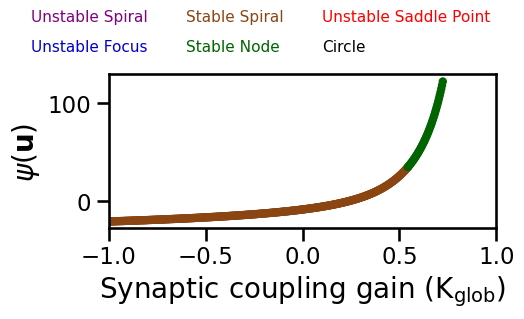

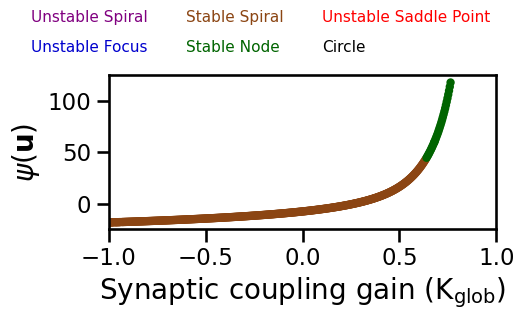

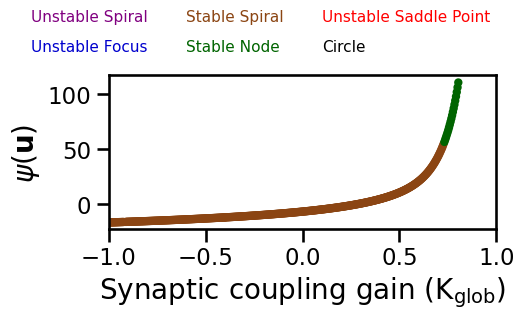

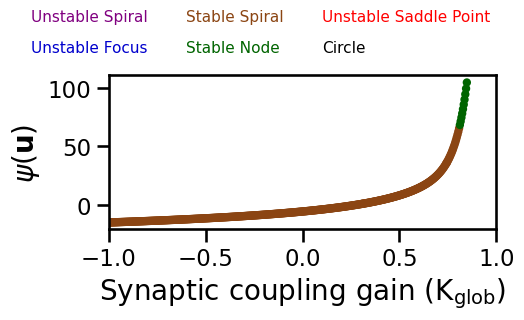

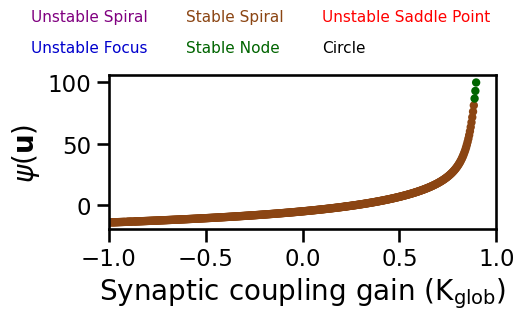

In [10]:
for filePath in filePathsSort:
    BaseName = os.path.basename(filePath).split('mV.pkl')[0]
    I = float(BaseName.split('_')[-1])
    Sig = float(BaseName.split('_')[3])

    if Sig != round(sigValues[-2], 3):
        continue
    
    with open(filePath, 'rb') as file_:
        DataDict = pickle.load(file_)
    
    file_str_k = f"Imod_{I:.3f}mV_sig_{Sig:.3f}.jpg"

    K = np.array(DataDict['fp_var'])

    DF = dimreduction(DataDict, xVar='I', **params)

    textDelt = max(DF['U']/ params['gamma']) * 0.5
    plt.figure(figsize=(5, 2))
    plt.scatter(K, DF['U'] / params['gamma'], c=DF['FP_types'], marker='.')
    plt.ylabel(r'$\psi(\mathbf{u})$', fontsize=20)
    plt.text(-1.4, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['purple'], c='purple')
    plt.text(0.1, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['red'], c='red')
    plt.text(0.1, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['black'], c='black')
    plt.text(-1.4, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['mediumblue'], c='mediumblue')

    plt.text(-0.6, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['darkgreen'], c='darkgreen')
    plt.text(-0.6, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['saddlebrown'], c='saddlebrown')
    plt.xlim(-1, 1)
    # plt.xticks(np.unique(Sig)[::5])
    plt.xlabel(r"Synaptic coupling gain $(\rm K_{glob})$", fontsize=20)

    plt.savefig(os.path.join(figureroot, file_str_k), dpi=300, bbox_inches='tight')

In [11]:
# Equilibria change with heterogeneity
load_dir = "../system_01/results/fp/"
load_str = datetime.datetime(2024, 4, 21)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

iPert = np.array([0.0, 0.15, 0.25, 0.35, 0.5]) / params['gamma']
kVals = np.array([-0.8, -0.2, 0.0, 0.2, 0.8])

Total no. of files = 25


In [12]:
filePaths = [path for path in file_paths if '_K_' in path]

# sorting based on K value
Ilookup = {}
Klookup = {}

for n, filePath in enumerate(filePaths):
    baseName = os.path.basename(filePath).split('.pkl')[0]
    I = float(baseName.split('_')[3])
    K = float(baseName.split('_')[-1])

    if I not in Ilookup.keys():
        Ilookup[I] = [filePath]
        Klookup[I] = [K]
    else:
        Ilookup[I].append(filePath)
        Klookup[I].append(K)
    

for key, vals in Klookup.items():
    K_ = np.array(vals)
    Ksort = np.argsort(K_)

    Ilookup[key] = np.array(Ilookup[key])[Ksort]

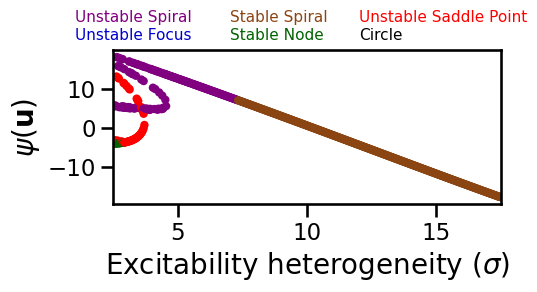

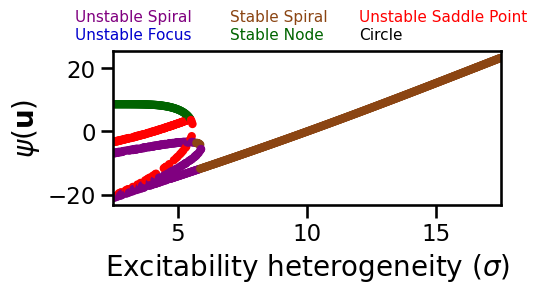

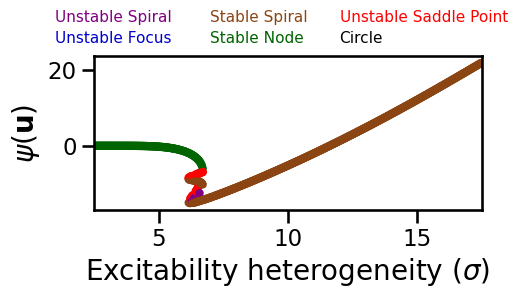

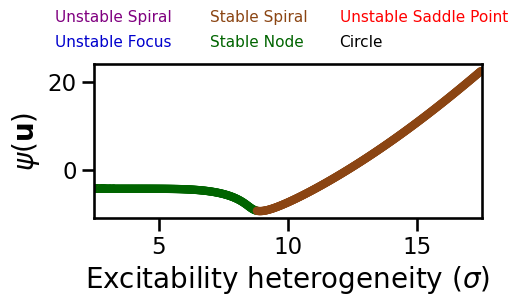

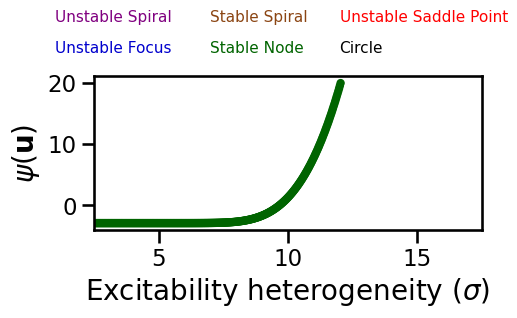

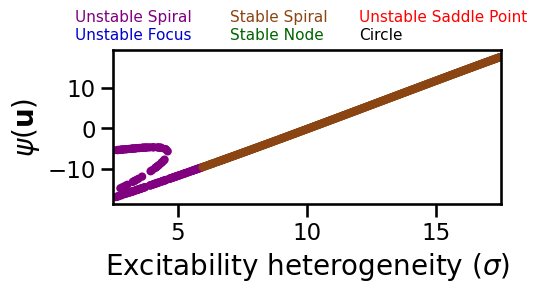

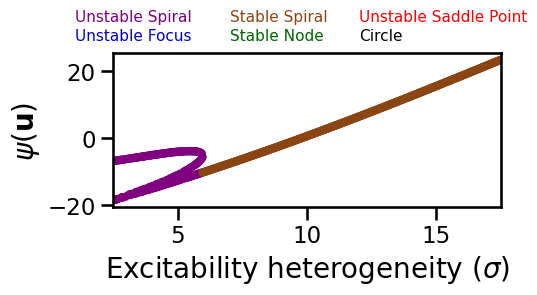

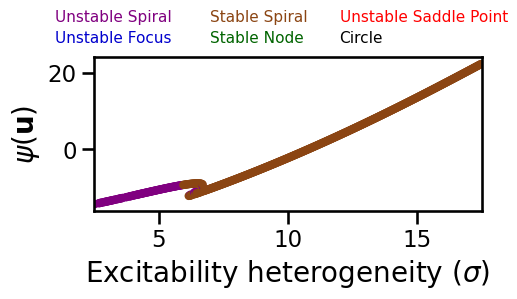

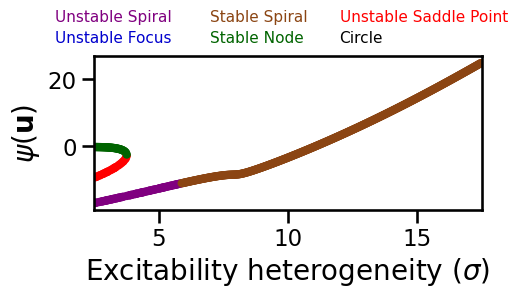

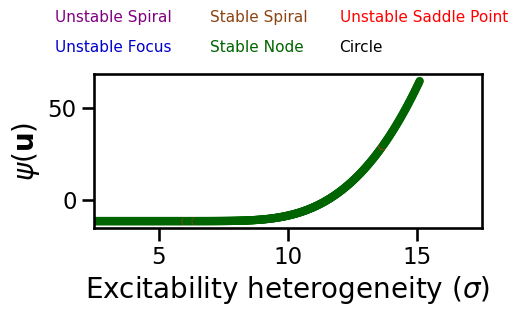

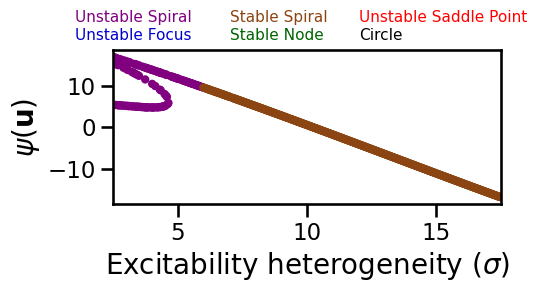

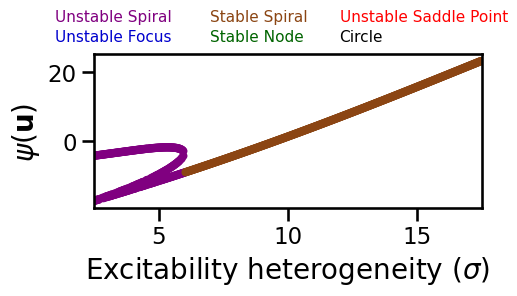

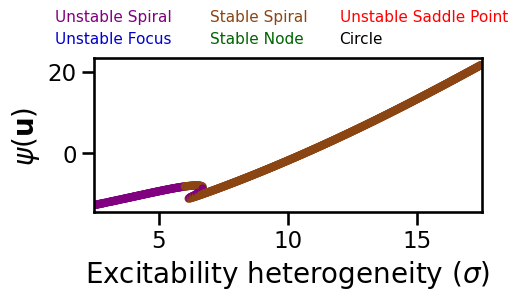

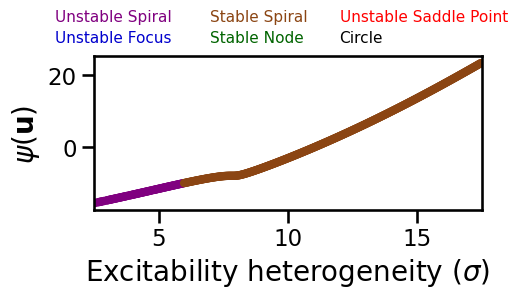

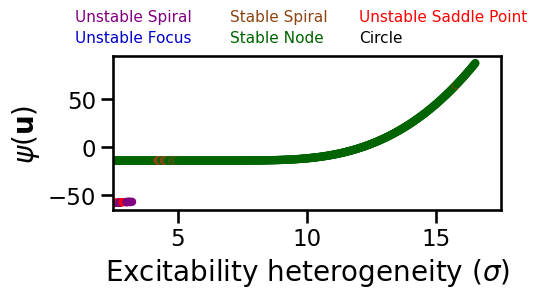

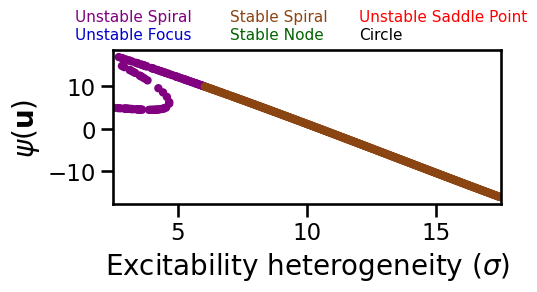

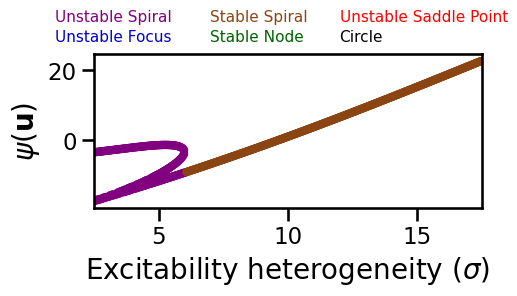

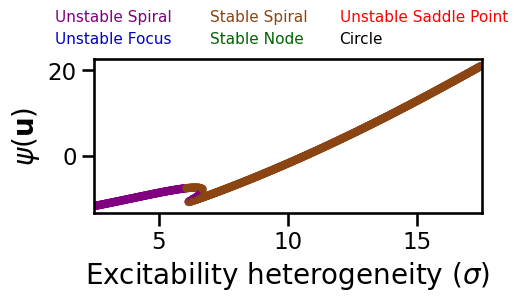

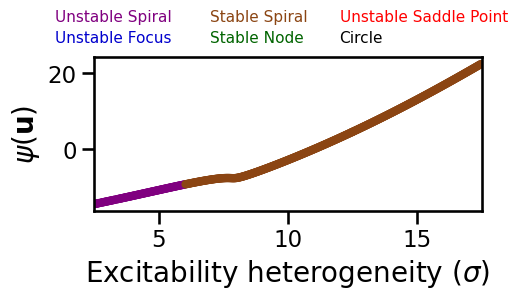

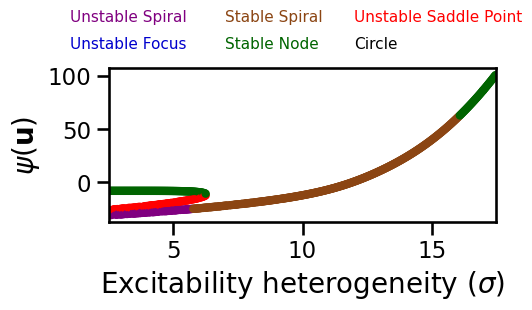

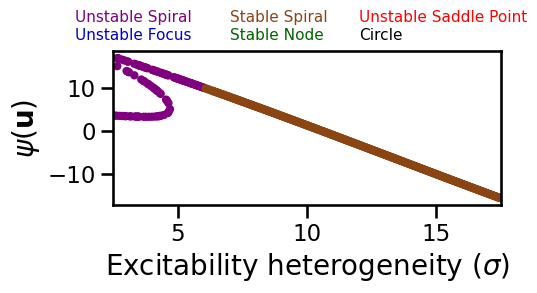

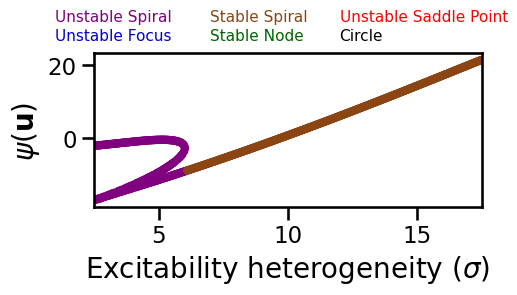

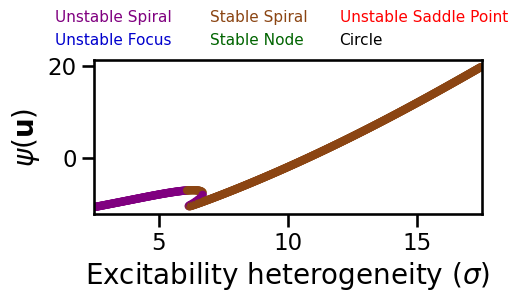

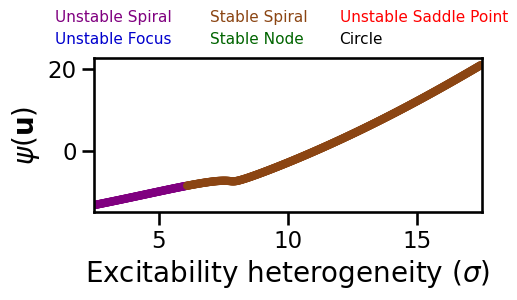

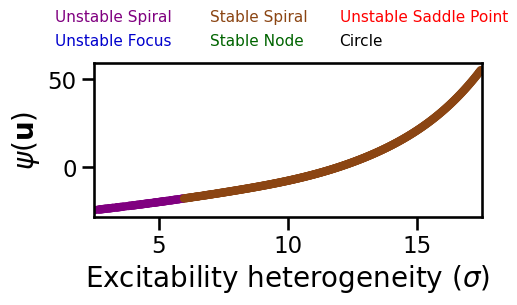

In [13]:
for iTarget in iPert:
    iTarget += params['i_e2']

    pathes_ = Ilookup[round(iTarget, 3)]

    for filePath in pathes_:
        BaseName = os.path.basename(filePath).split('.pkl')[0]
        K = float(BaseName.split('_')[-1])
        I = float(BaseName.split('_')[3]) - params['i_e2']

        file_str_k = f"K_{K:.3f}_Imod_{I:.3f}mV.jpg"
      
        with open(filePath, 'rb') as file_:
            DataDict = pickle.load(file_)
        
        Sig = np.array(DataDict['fp_var'])

        DF = dimreduction(DataDict, xVar='Sig', **params)

        textDelt = max(DF['U']/ params['gamma']) * 0.5
        plt.figure(figsize=(5, 2))
        plt.scatter(Sig, DF['U'] / params['gamma'], c=DF['FP_types'], marker='.')
        plt.ylabel(r'$\psi(\mathbf{u})$', fontsize=20)
        plt.text(1, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['purple'], c='purple')
        plt.text(12, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['red'], c='red')
        plt.text(12, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['black'], c='black')
        plt.text(1, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['mediumblue'], c='mediumblue')

        plt.text(7, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['darkgreen'], c='darkgreen')
        plt.text(7, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['saddlebrown'], c='saddlebrown')
        plt.xlim(2.5, 17.5)
        # plt.xticks(np.unique(Sig)[::5])
        plt.xlabel(r"Excitability heterogeneity $(\sigma)$", fontsize=20)

        plt.savefig(os.path.join(figureroot, file_str_k), dpi=300, bbox_inches='tight')

In [14]:
# Multi-region summarization

load_dir = "../system_01/results/fp/"
load_str = datetime.datetime(2023, 12, 15)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

file_name = f'scene01_data_final.pkl'

Total no. of files = 4


In [15]:
def smooth(y, nWindow, polyOrder=2):
    y_smooth = sp.signal.savgol_filter(y, nWindow, polyOrder, mode='nearest')
    return y_smooth

In [16]:
with open(os.path.join(results_dir, file_name), 'rb') as file_:
    fp_data = pickle.load(file_)

fp_df = pd.DataFrame.from_dict(fp_data)
fp_df = fp_df.sort_values(by = ['I', 'K', 'sigma'], ascending = [True, True, True])

In [17]:
I_uniq = fp_df['I'].unique()
sigma_uniq = fp_df['sigma'].unique()
K_uniq = fp_df['K'].unique()

nIvals = len(I_uniq)
nSigvals = len(sigma_uniq)
nKvals = len(K_uniq)

print(f"Unique I's = {nIvals} | sigma's = {nSigvals} | K's = {nKvals}")

Unique I's = 51 | sigma's = 50 | K's = 51


In [18]:
deltaI_arr = np.zeros((nKvals, nSigvals))
MultiI = np.zeros((nKvals, nSigvals))

for nK, K in enumerate(K_uniq):
    if nK % 10 == 0:
        print(f'Ealuating multi-region width for K = {K:.3f}')
    for nS, sigma_ in enumerate(sigma_uniq):
        
        df_sub = fp_df[(fp_df['sigma'] == sigma_) & (fp_df['K'] == K)]

        fp_counts_dict = df_sub['I'].value_counts().sort_index().to_dict()

        I = np.array(list(fp_counts_dict.keys()))
        Isort = np.argsort(I)
        I = I[Isort]

        FP_count = np.array(list(fp_counts_dict.values()))
        FP_count = FP_count[Isort]

        MultiR_id = np.where(FP_count > 1)[0]

        if len(MultiR_id) == 0:
            continue

        Mult_diffid = np.diff(MultiR_id)

        markers = np.where(Mult_diffid > 4)[0] + 1
        nRegions = len(markers)

        if nRegions:
            segment_delt = []
            start_marker = 0

            for i in range(nRegions + 1):
                if i !=  nRegions:
                    marker = markers[i]
                    segment = MultiR_id[start_marker:marker]
                else:
                    segment = MultiR_id[start_marker:]
                
                if i < nRegions:
                    start_marker = marker

                segment_delt.append(I[segment[-1]] - I[segment[0]]) if len(segment) > 0 else 0

            deltaI_arr[nK, nS] = max(segment_delt)
            MultiI[nK, nS] = len(segment_delt)

        else:
            MultiI[nK, nS] += 1
            deltaI_arr[nK, nS] = I[MultiR_id[-1]] - I[MultiR_id[0]]

Ealuating multi-region width for K = -1.000
Ealuating multi-region width for K = -0.600
Ealuating multi-region width for K = -0.200


Ealuating multi-region width for K = 0.160
Ealuating multi-region width for K = 0.560
Ealuating multi-region width for K = 0.960


In [19]:
K0indx = np.where(K_uniq == 0)[0][0]
MultiI = np.delete(MultiI, (K0indx), axis=0)

K = K_uniq[K0indx]

K0df = fp_df[['I', 'K', 'sigma', 'ue1']]
K0df = K0df[(K0df['K'] == K)]

K0df = K0df.drop_duplicates(subset=['ue1'])

Uncoupled = np.zeros(nSigvals)

for nS, sigma_ in enumerate(sigma_uniq):
        
    df_sub = K0df[(K0df['sigma'] == sigma_)]

    fp_counts_dict = df_sub['I'].value_counts().sort_index().to_dict()

    I = np.array(list(fp_counts_dict.keys()))
    Isort = np.argsort(I)
    I = I[Isort]

    FP_count = np.array(list(fp_counts_dict.values()))
    FP_count = FP_count[Isort]

    MultiR_id = np.where(FP_count > 1)[0]

    if len(MultiR_id) == 0:
        continue

    Mult_diffid = np.diff(MultiR_id)

    markers = np.where(Mult_diffid > 4)[0] + 1
    nRegions = len(markers)

    if nRegions:
        segment_delt = []
        start_marker = 0

        for i in range(nRegions + 1):
            if i !=  nRegions:
                marker = markers[i]
                segment = MultiR_id[start_marker:marker]
            else:
                segment = MultiR_id[start_marker:]
            
            if i < nRegions:
                start_marker = marker

            segment_delt.append(I[segment[-1]] - I[segment[0]]) if len(segment) > 0 else 0

        Uncoupled[nS] = max(segment_delt)

    else:
        Uncoupled[nS] = I[MultiR_id[-1]] - I[MultiR_id[0]]

deltaI_arr[K0indx] = Uncoupled

In [20]:
smoothDeltI = deepcopy(deltaI_arr)
cMap = ListedColormap(["black", "white"])

for nI in range(nIvals):
    smoothDeltI[nI, :] = smooth(deltaI_arr[nI, :], nWindow=7, polyOrder=3)

encodeDeltaI = deepcopy(smoothDeltI)
encodeDeltaI[encodeDeltaI > 0.000] = 1
encodeDeltaI[encodeDeltaI <= 0.000] = 0

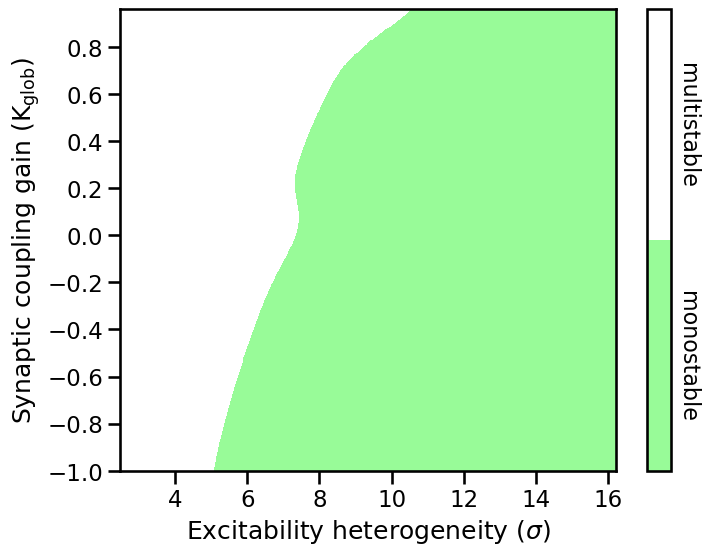

In [21]:
fileName = 'MultiStable_DeltaI.jpg'

response = deepcopy(encodeDeltaI)
mask = response == np.inf 
response[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), response[~mask])

y, x, r = cv_upsample(orig_response=response, eval_arrx=sigma_uniq, eval_arry=K_uniq, 
                            y_max=max(K_uniq), y_min=min(K_uniq), x_max=max(sigma_uniq), x_min=min(sigma_uniq),
                            sigma_x = 25, sigma_y = 25,  resolution = 500 ) 


plt.figure(figsize=(8, 6))
cMap = ListedColormap(["palegreen", "white"])
heatmap = plt.pcolormesh(x, y, r, cmap=cMap)
cbar = plt.colorbar(heatmap, pad=0.05)

cbar.ax.get_yaxis().set_ticks([])
cbar.ax.text(1.75, 0.5 , r"multistable", rotation=270, ha='center', va='center', fontsize=16)
cbar.ax.text(1.75, -0.5 , r"monostable", rotation=270, ha='center', va='center', fontsize=16)
plt.ylabel(r"Synaptic coupling gain $(\rm K_{glob})$", fontsize=18); plt.xlabel(r"Excitability heterogeneity $(\sigma)$", fontsize=18)
plt.yticks(list(K_uniq[:30:5]) + list(K_uniq[31::5]))
plt.savefig(os.path.join(figureroot, fileName), dpi=300, bbox_inches='tight')
plt.show()

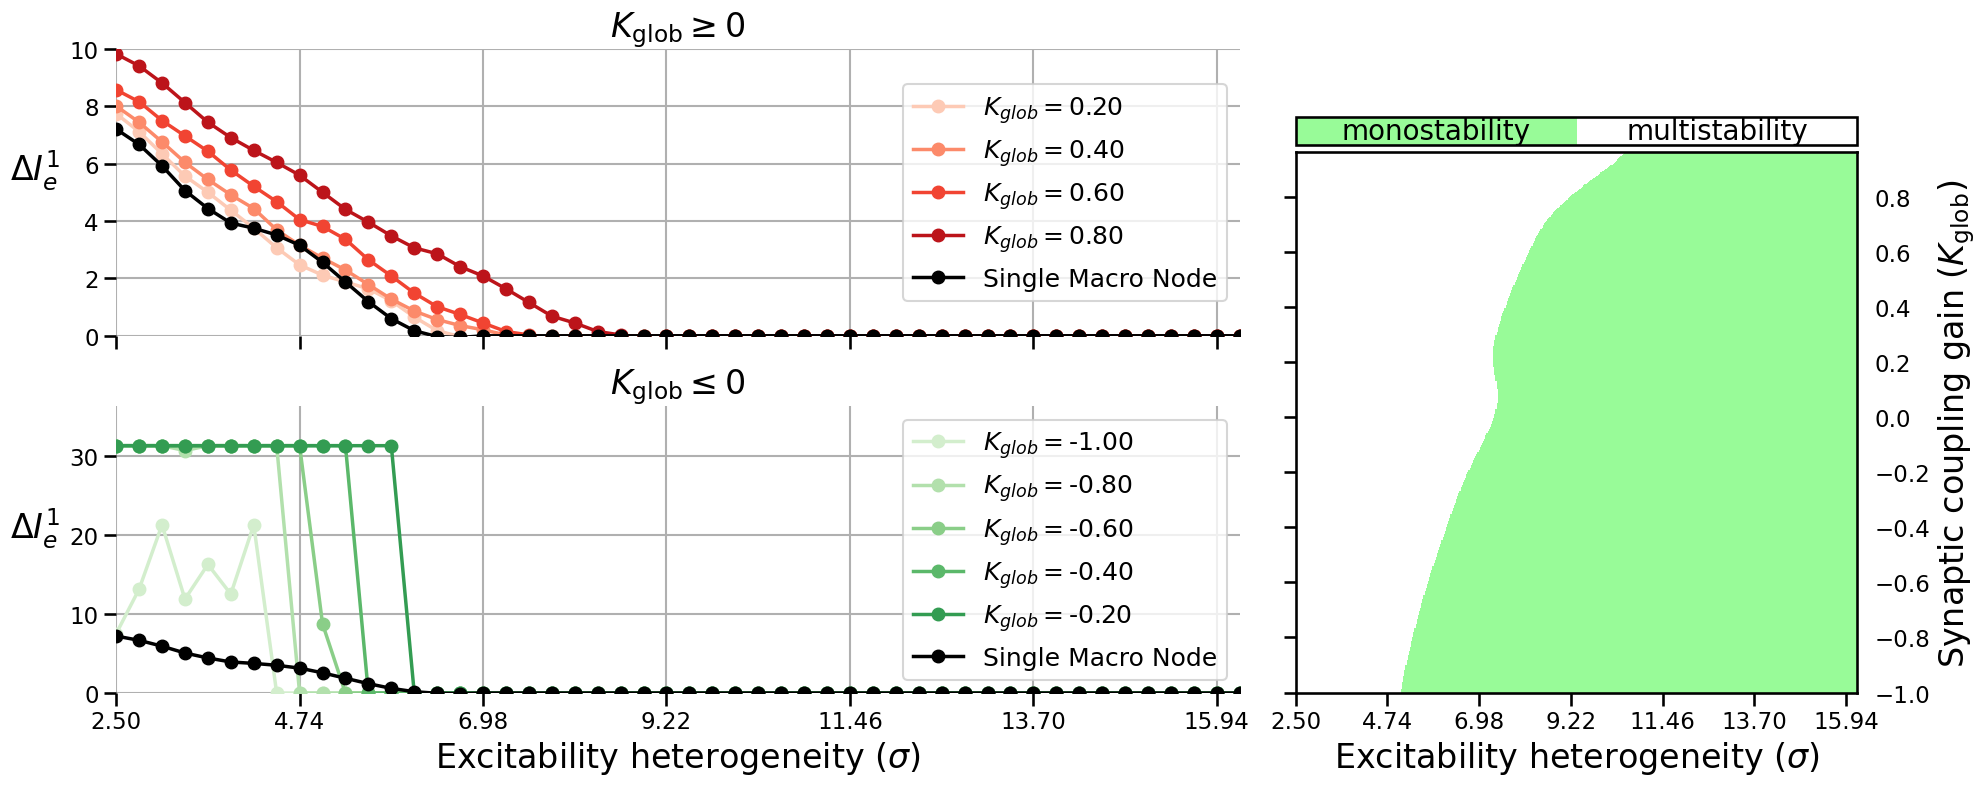

In [22]:
fileName = 'MultiStable_DeltaI_Full.pdf'

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(20, 8),  gridspec_kw={'width_ratios':[2,1]})
 
max_ylim = 0

for pos in ['left', 'top', 'bottom', 'right']:
    axs[0][0].spines[pos].set_visible(False)
    axs[1][0].spines[pos].set_visible(False)

colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.2, 0.8, len(K_uniq[31::5]))))

for nK in range(31, nKvals, 5):
    if round(K_uniq[nK], 2) == 0 or K_uniq[nK] < 0:
        continue

    color = next(colorIter)
    max_ylim = max(max_ylim, max(deltaI_arr[nK, :]))
    axs[0][0].plot(sigma_uniq, smooth(deltaI_arr[nK, :], nWindow=7, polyOrder=3), '-o', color=color, linewidth=2.5, label=r"$K_{glob} = $" + f"{K_uniq[nK]:.2f}")

axs[0][0].plot(sigma_uniq, smooth(Uncoupled, nWindow=7, polyOrder=3), 'k-o', linewidth=2.5, label=r"Single Macro Node")

axs[0][0].set_xlim(sigma_uniq[0], sigma_uniq[-1])
axs[0][0].set_ylim(0, max_ylim)
axs[0][0].set_ylabel(r"$\Delta I^1_e$", rotation=0, labelpad=25, fontsize=24)
axs[0][0].legend(loc = 'center right', bbox_to_anchor=(1., 0.5), fontsize=18)
axs[0][0].set_title(r"$K_{\rm glob} \geq 0$", fontsize=24)
axs[0][0].grid(True)


max_ylim = 0

colors= plt.get_cmap('Greens')
colorIter = iter(colors(np.linspace(0.2, 0.8, len(K_uniq[0:30:5]))))

for nK in range(0, nKvals, 5):
    if round(K_uniq[nK], 2) == 0 or K_uniq[nK] > 0:
        continue
    color = next(colorIter)
    max_ylim = max(max_ylim, max(deltaI_arr[nK, :]))
    axs[1][0].plot(sigma_uniq, smooth(deltaI_arr[nK, :], nWindow=3, polyOrder=2), '-o', color=color, linewidth=2.5, label=r"$K_{glob} = $" + f"{K_uniq[nK]:.2f}")

axs[1][0].plot(sigma_uniq, smooth(Uncoupled, nWindow=7, polyOrder=3), 'k-o', linewidth=2.5, label=r"Single Macro Node")

axs[1][0].set_xlim(sigma_uniq[0], sigma_uniq[-1])
axs[1][0].set_xticks(sigma_uniq[::8])
axs[1][0].set_ylim(0, max_ylim + 5)
axs[1][0].set_ylabel(r"$\Delta I^1_e$", rotation=0, labelpad=25, fontsize=24)
axs[1][0].set_xlabel(r"Excitability heterogeneity $(\sigma)$", fontsize=24)
axs[1][0].legend(loc = 'center right', bbox_to_anchor=(1., 0.5), fontsize=18)
axs[1][0].set_title(r"$K_{\rm glob} \leq 0$", fontsize=24)
axs[1][0].grid(True)

gs = axs[0, 1].get_gridspec()
for ax in axs[0:, -1]:
    ax.remove()
axsbig = fig.add_subplot(gs[0:, -1])
axsbig.tick_params(axis='y', which='both', labelleft=False, labelright=True)
axsbig.yaxis.set_label_position("right")


response = deepcopy(encodeDeltaI)
mask = response == np.inf 
response[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), response[~mask])

y, x, r = cv_upsample(orig_response=response, eval_arrx=sigma_uniq, eval_arry=K_uniq, 
                            y_max=max(K_uniq), y_min=min(K_uniq), x_max=max(sigma_uniq), x_min=min(sigma_uniq),
                            sigma_x = 25, sigma_y = 25,  resolution = 500 ) 

cMap = ListedColormap(["palegreen", "white"])
heatmap = plt.pcolormesh(x, y, r, cmap=cMap)
cbar = fig.colorbar(heatmap, ax=axsbig, location='top', pad=0.01)

cbar.ax.get_xaxis().set_ticks([])
cbar.ax.text(0.5, .5 , r"multistability", ha='center', va='center', fontsize=20)
cbar.ax.text(-0.5, 0.5 , r"monostability", ha='center', va='center', fontsize=20)
axsbig.set_ylabel(r"Synaptic coupling gain $(K_{\rm glob})$", fontsize=24); axsbig.set_xlabel(r"Excitability heterogeneity $(\sigma)$", fontsize=24)
axsbig.set_yticks(list(K_uniq[:30:5]) + list(K_uniq[31::5]))
axsbig.set_xticks(sigma_uniq[::8])
axsbig.set_xlim(min(sigma_uniq), max(sigma_uniq))
plt.tight_layout()

plt.savefig(os.path.join(figureroot, fileName), dpi=300, bbox_inches='tight')
plt.show()